In [ ]:
%load_ext autoreload
%autoreload 2

import parse_data
output_path = "INPUT OUTPUT PATH HERE"
global_sd = 0.01

In [3]:
# Cell to calculate all the information to parse the information from the file 
# Need to develop a system to create a new file that's easier and faster to read the data from

import matplotlib.pyplot as plt
import numpy as np    
from scipy import stats
import statistics
import math

# This is my own .py file, with methods that I have created myself.
import parse_data

pop_size = 2000
burnin = 4*pop_size

# Set global theme settings for plotting
plt.rcParams.update({
    'font.size': 20,          # Set font size
    'lines.linewidth': 3,     # Set default line thickness
    'axes.titlesize': 20,     # Title font size
    'axes.labelsize': 18,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,    # Y-tick label font size
    'grid.color': 'gray',     # Grid color
    'grid.linestyle': '--',   # Grid line style
    'grid.linewidth': 0.5,    # Grid line width
    'legend.fontsize': 16     # Legend font size
})

uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
wanted = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
uds.sort(); wanted.sort()


# These are important to remember
# parse_exp([uds], sd, BURNIN, COMMA)
data, timesteps = parse_data.parse_normal_from_exp(wanted, global_sd, True)
sliced_data, sliced_timesteps = parse_data.slice_data(data, timesteps, burnin)
# sliced_data's format = (sd, (ud, f. sel. deaths))



---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.01
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.02
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.03
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.05
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.075
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 

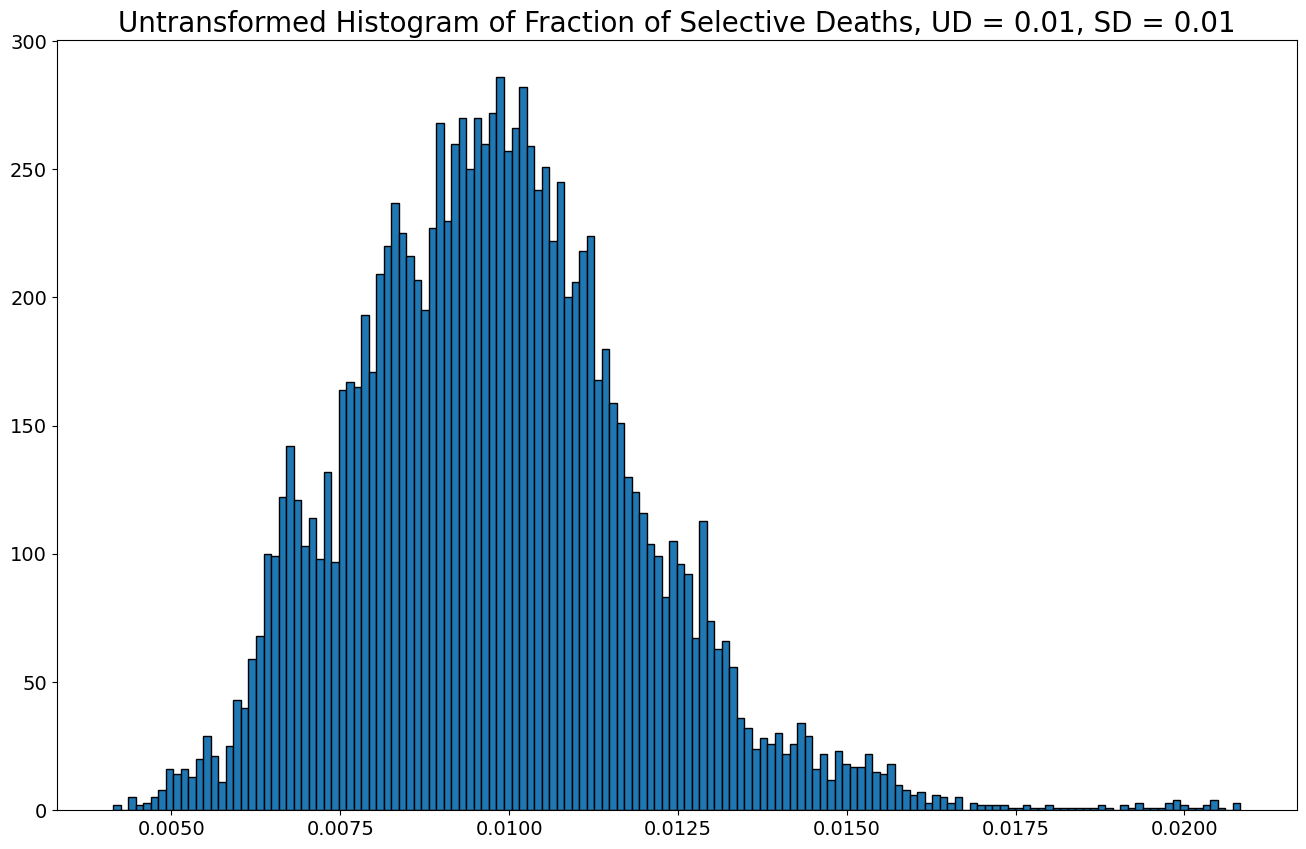

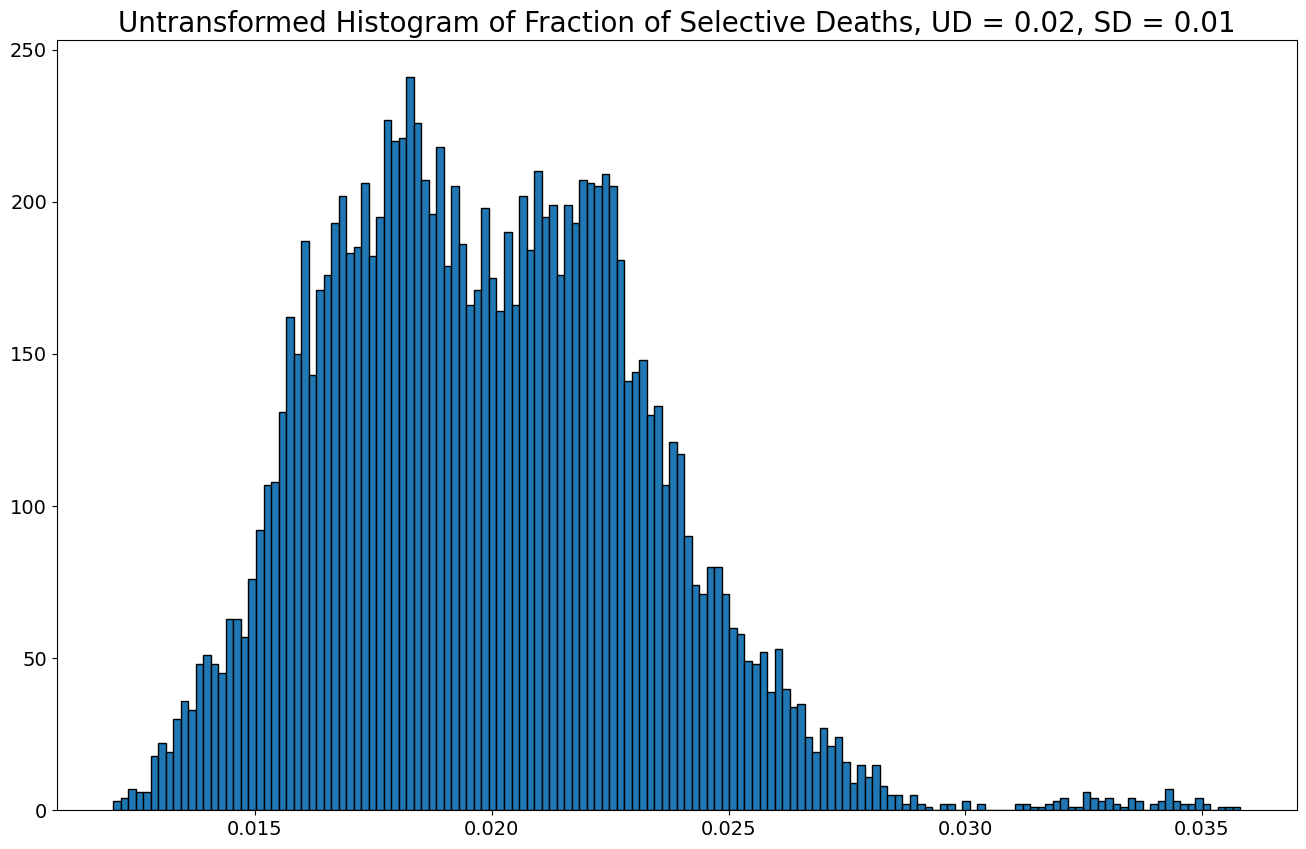

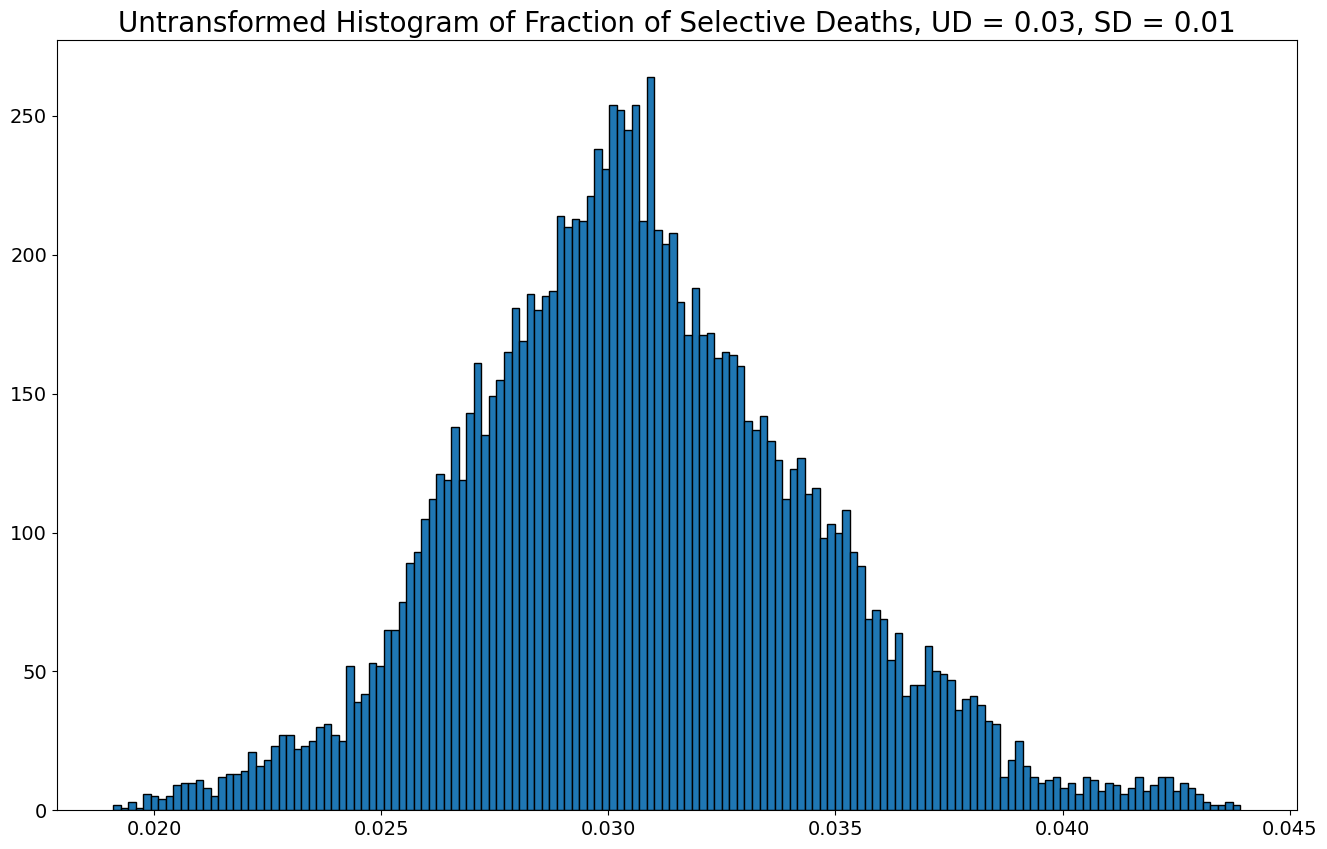

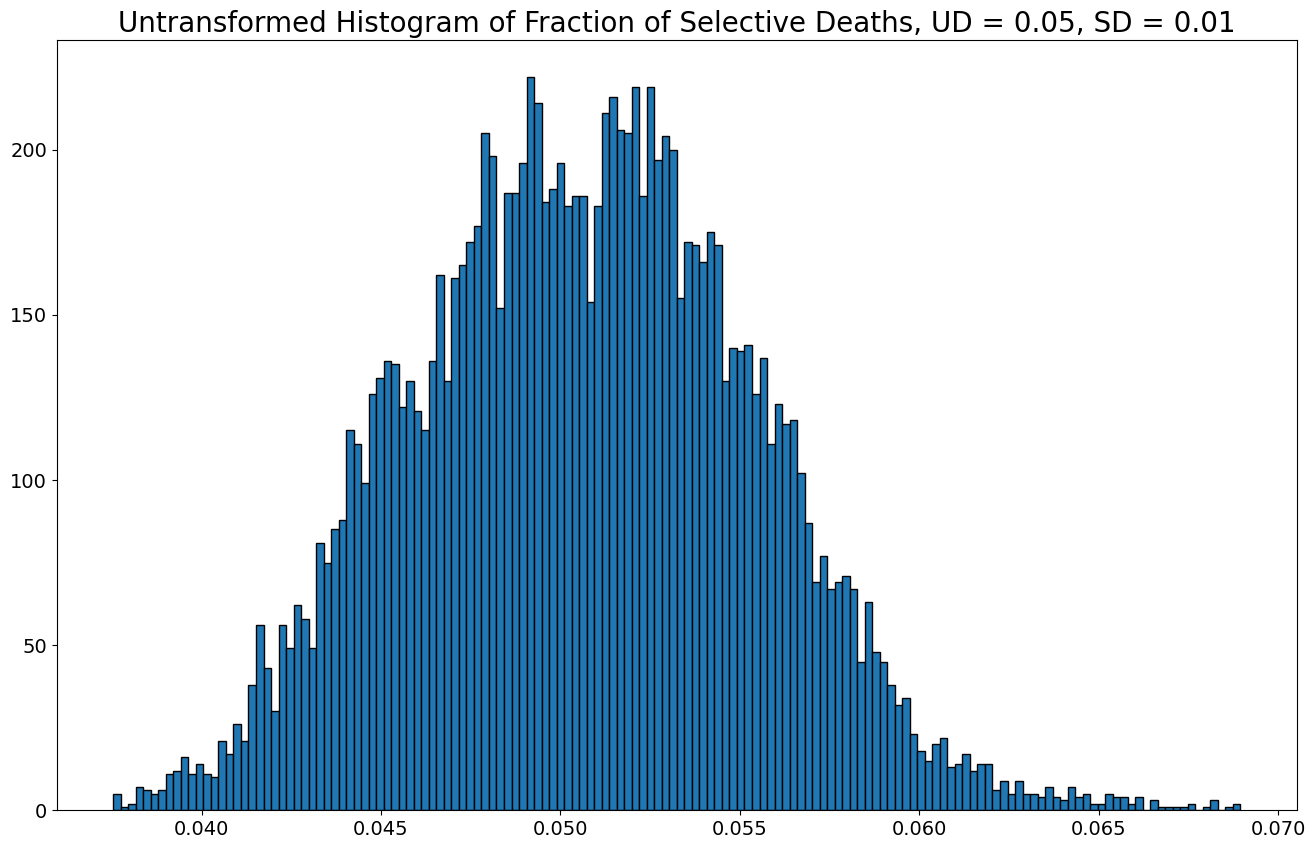

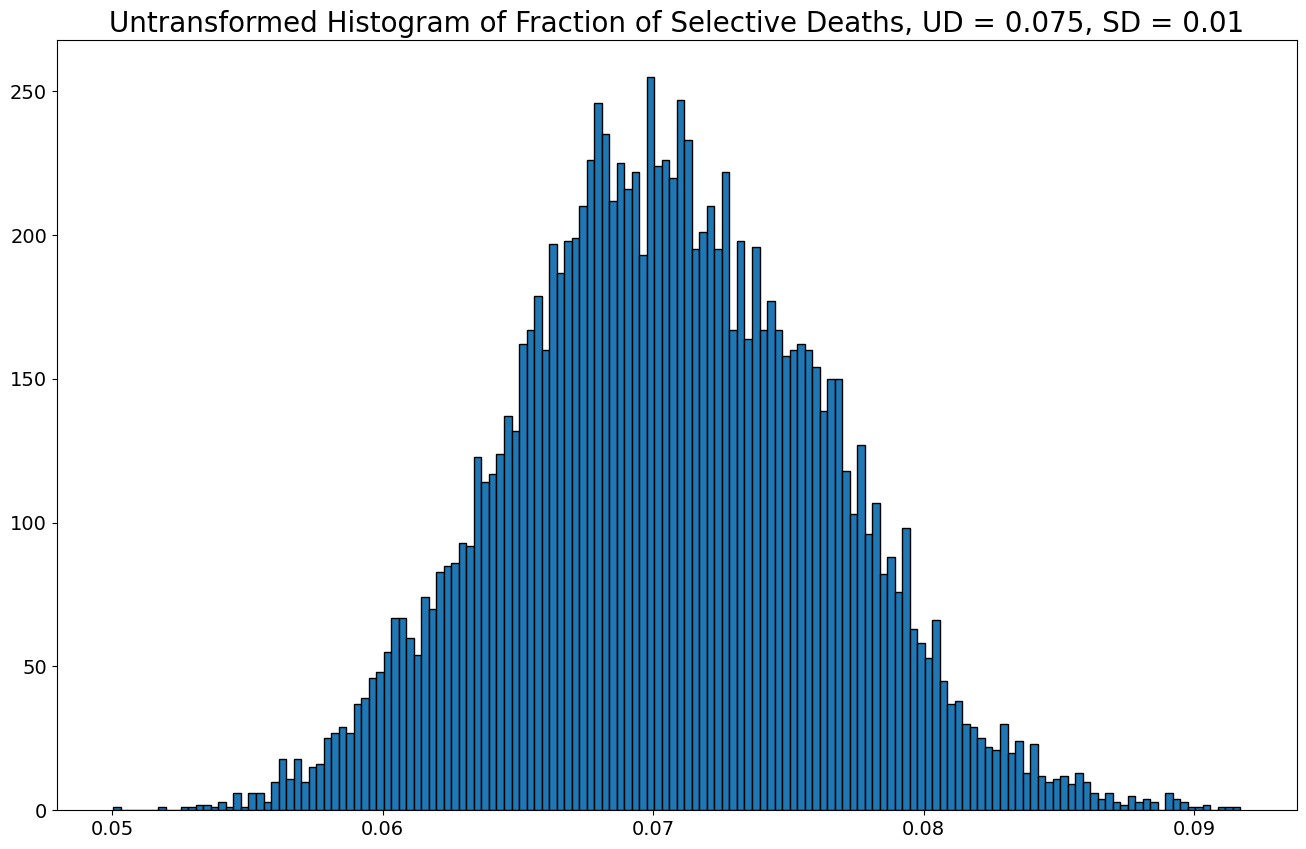

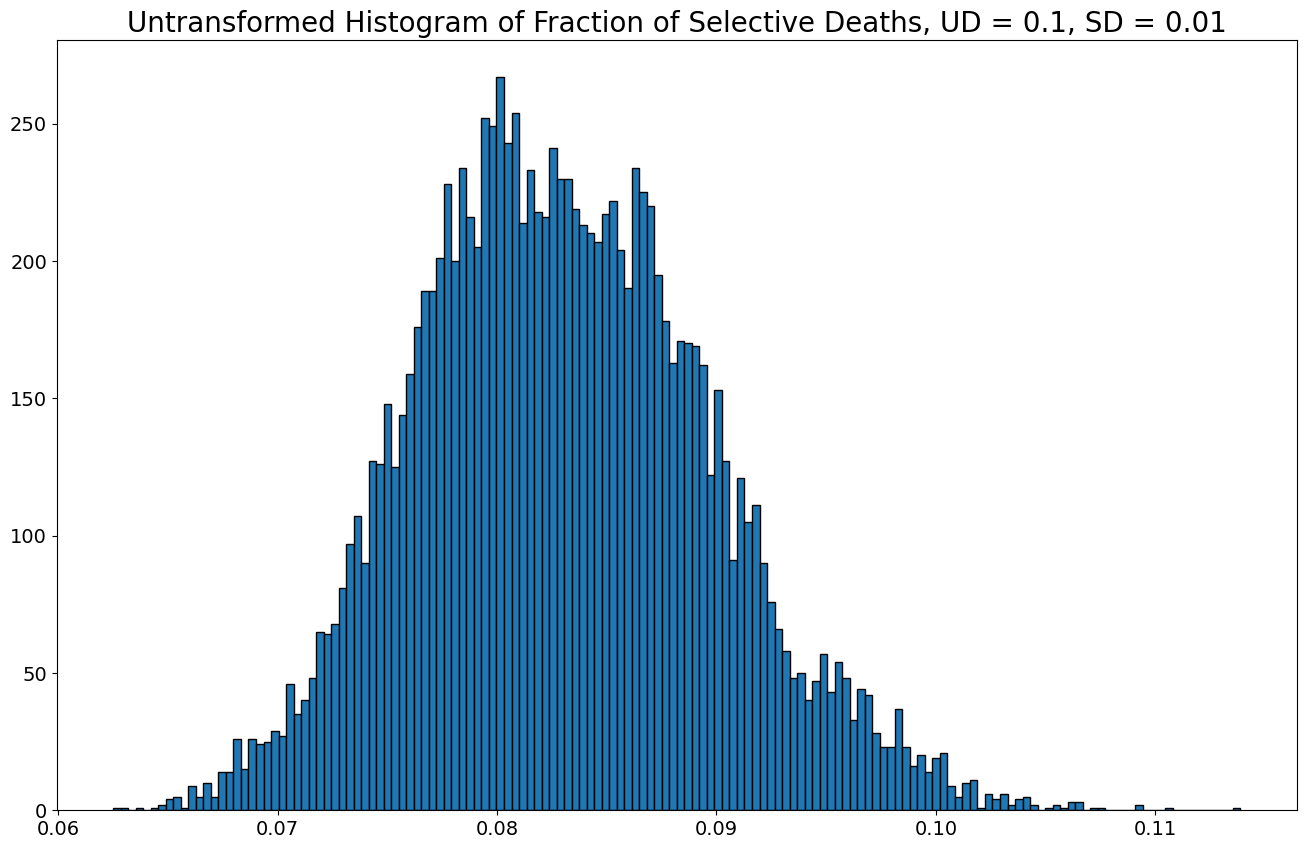

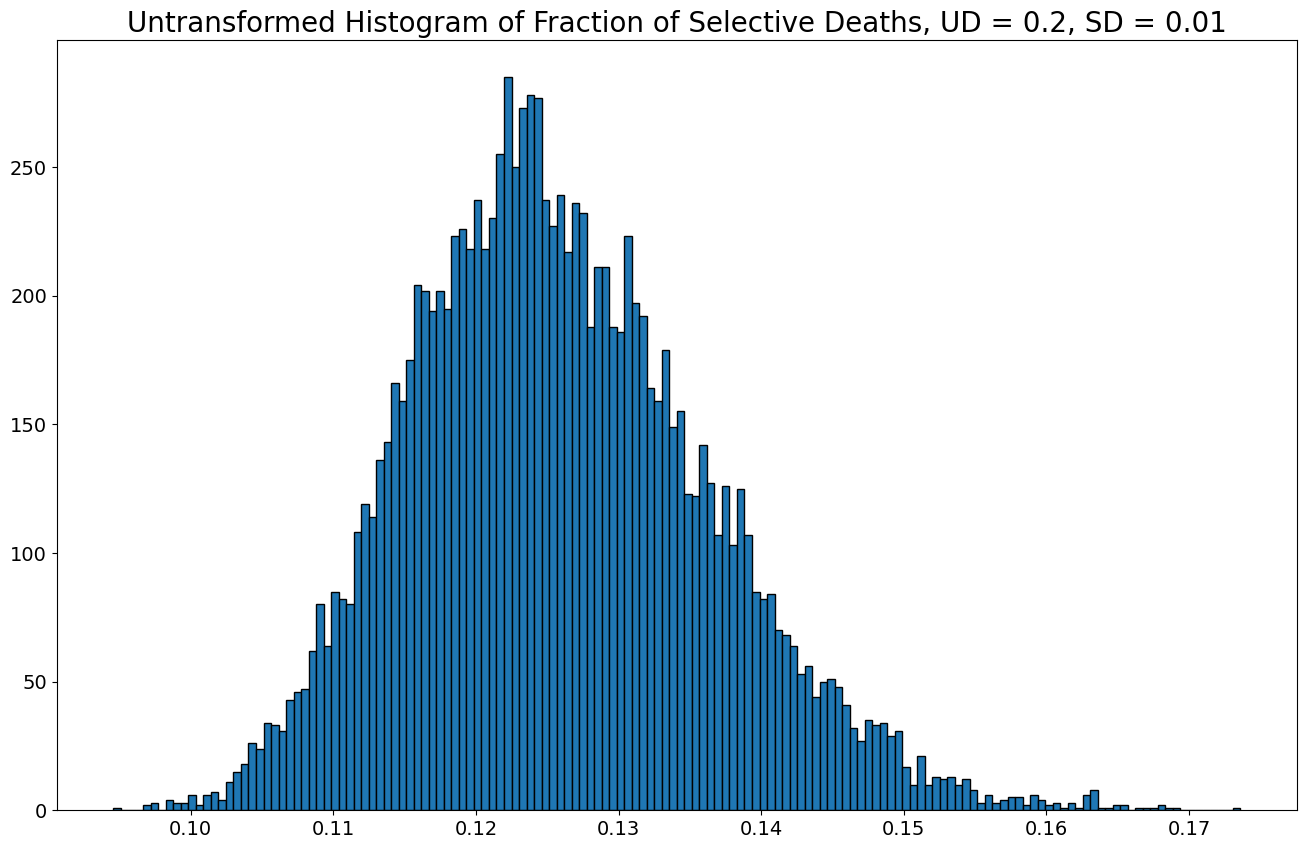

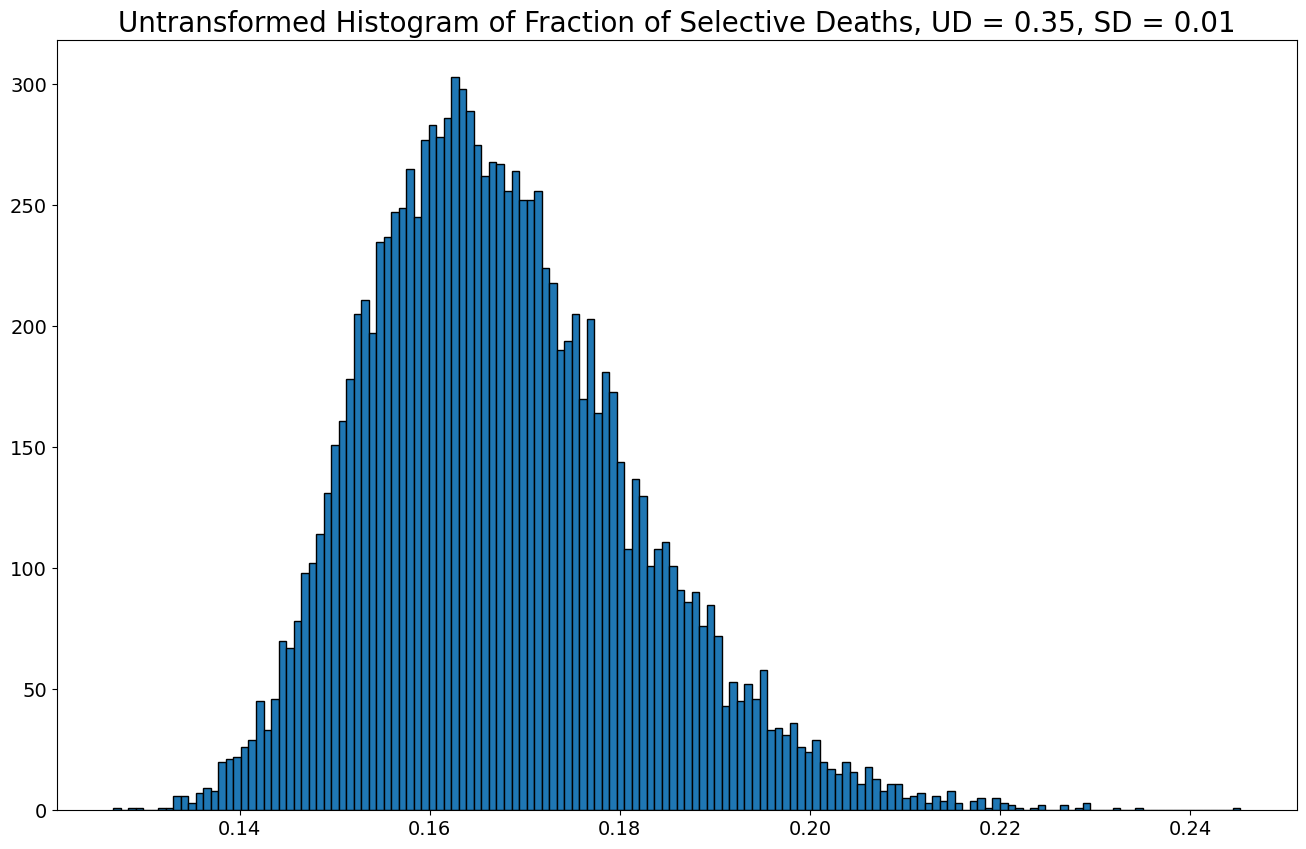

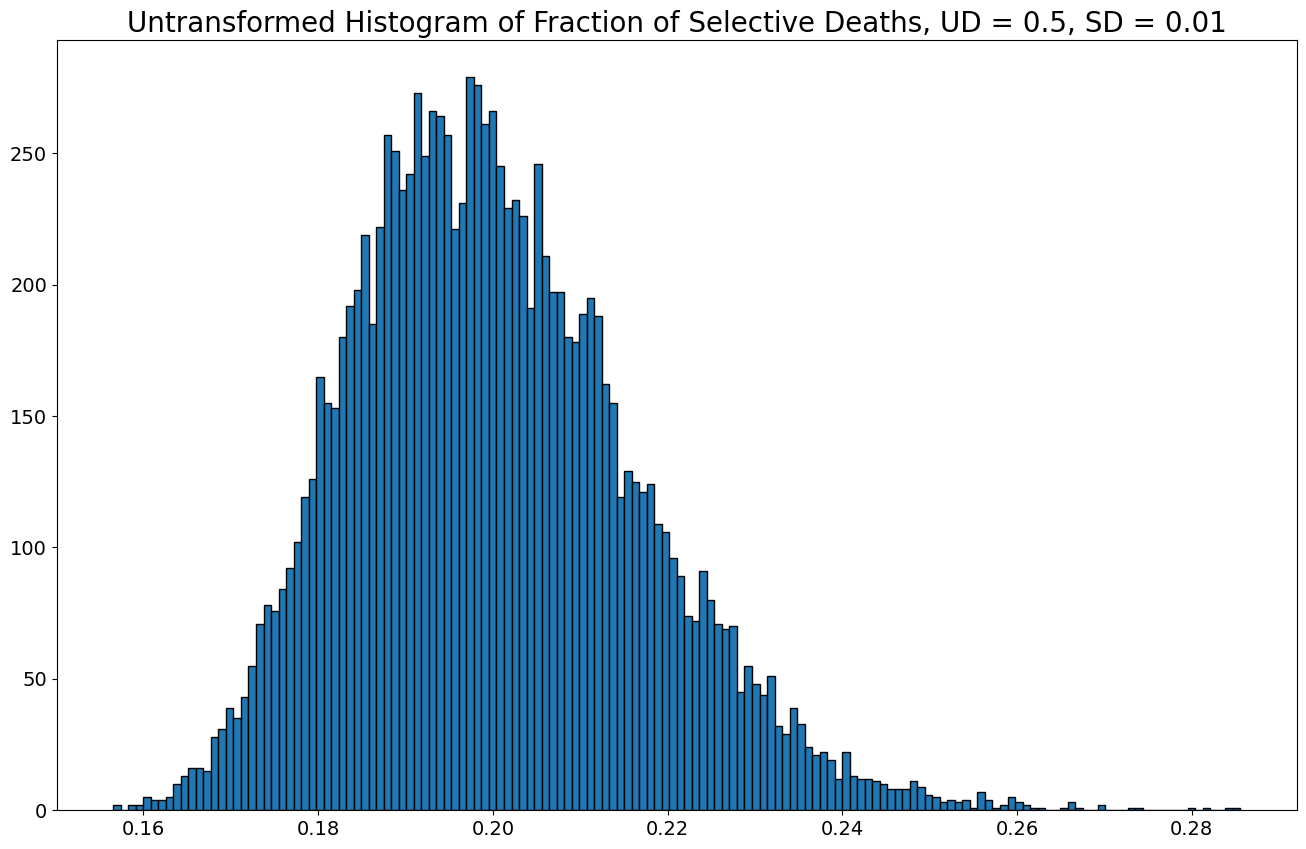

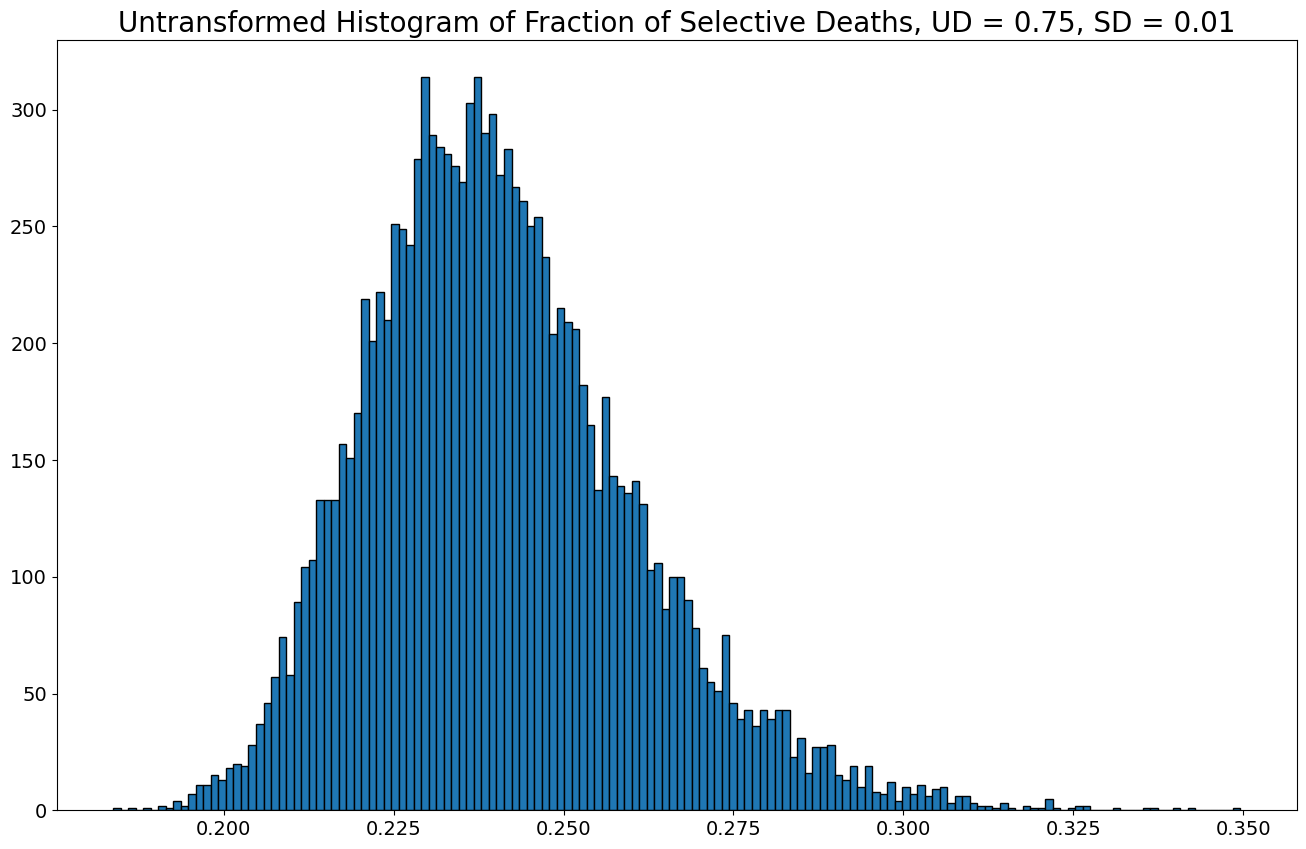

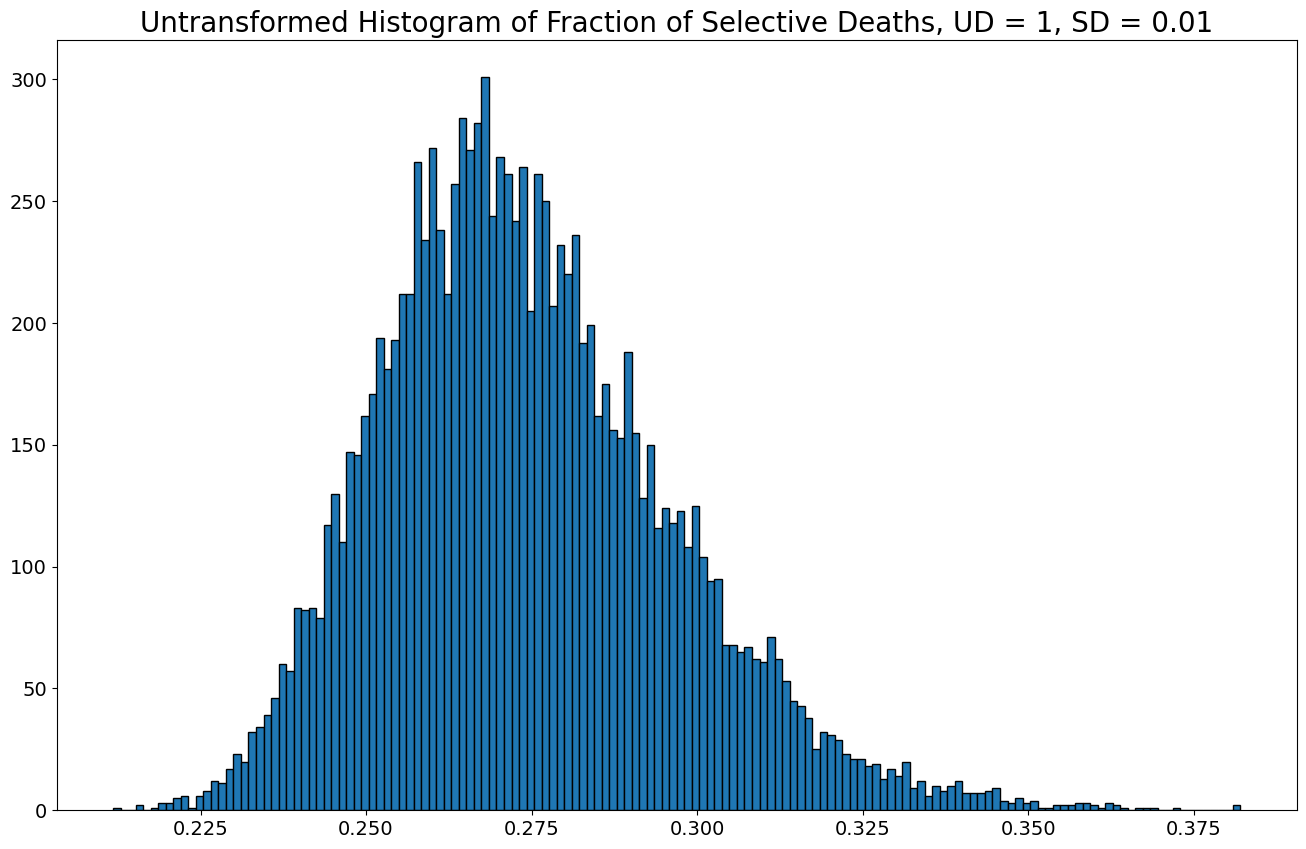

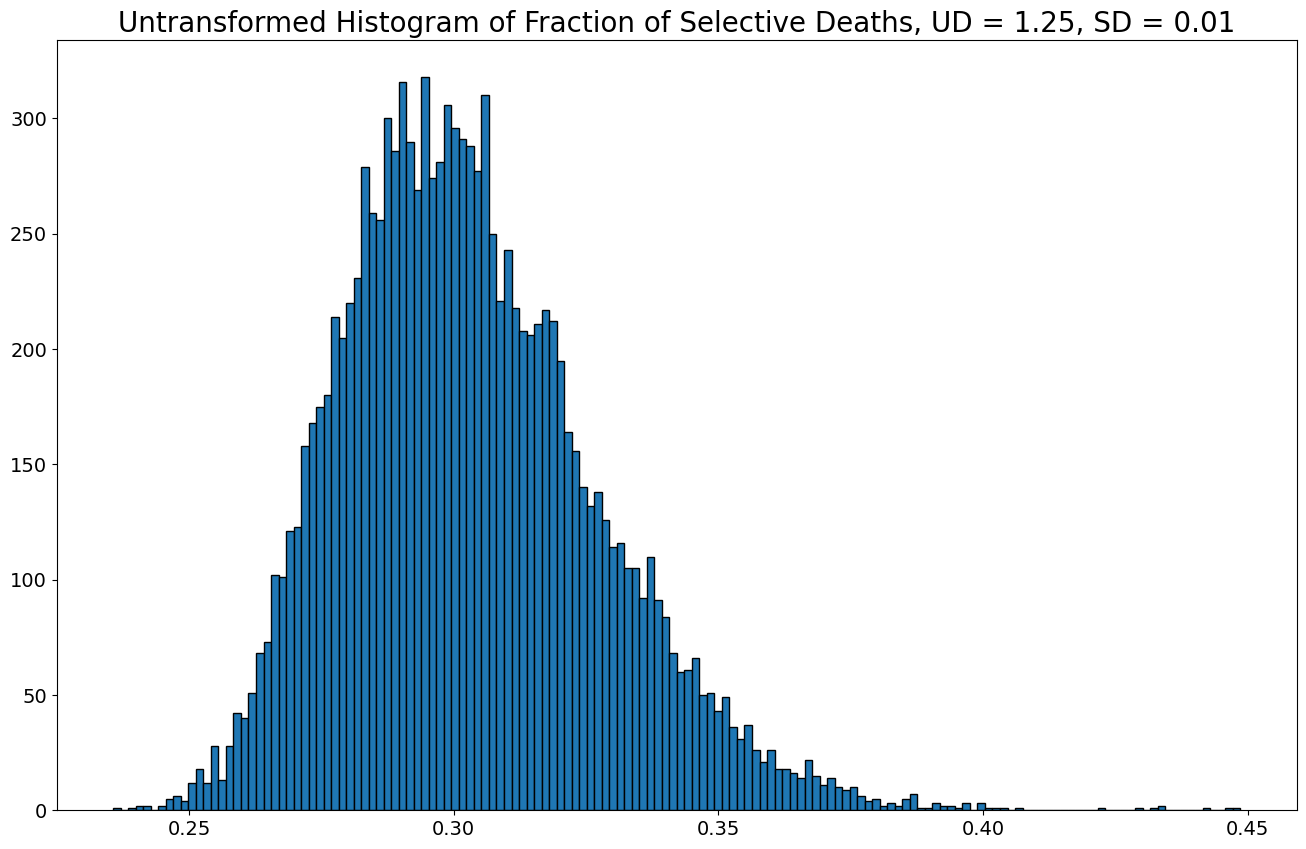

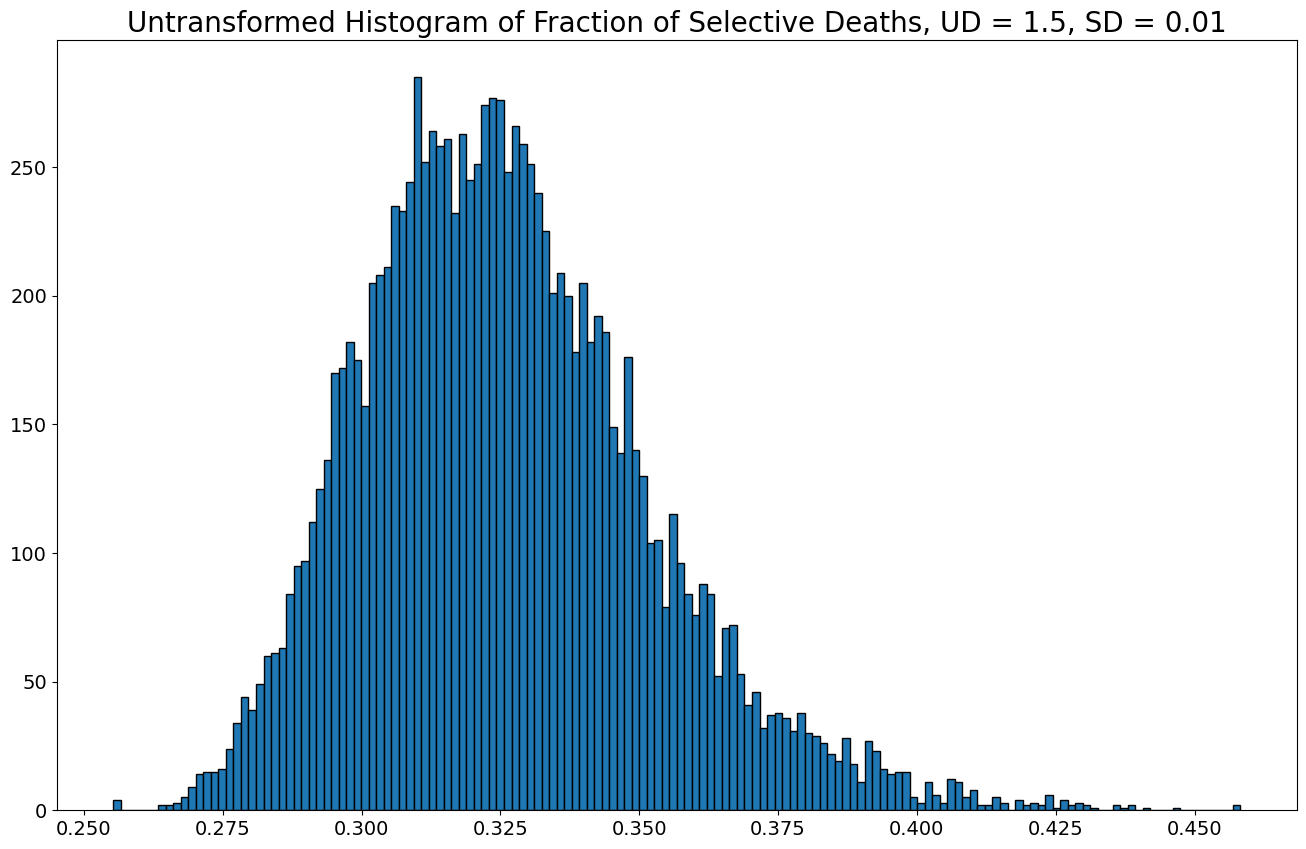

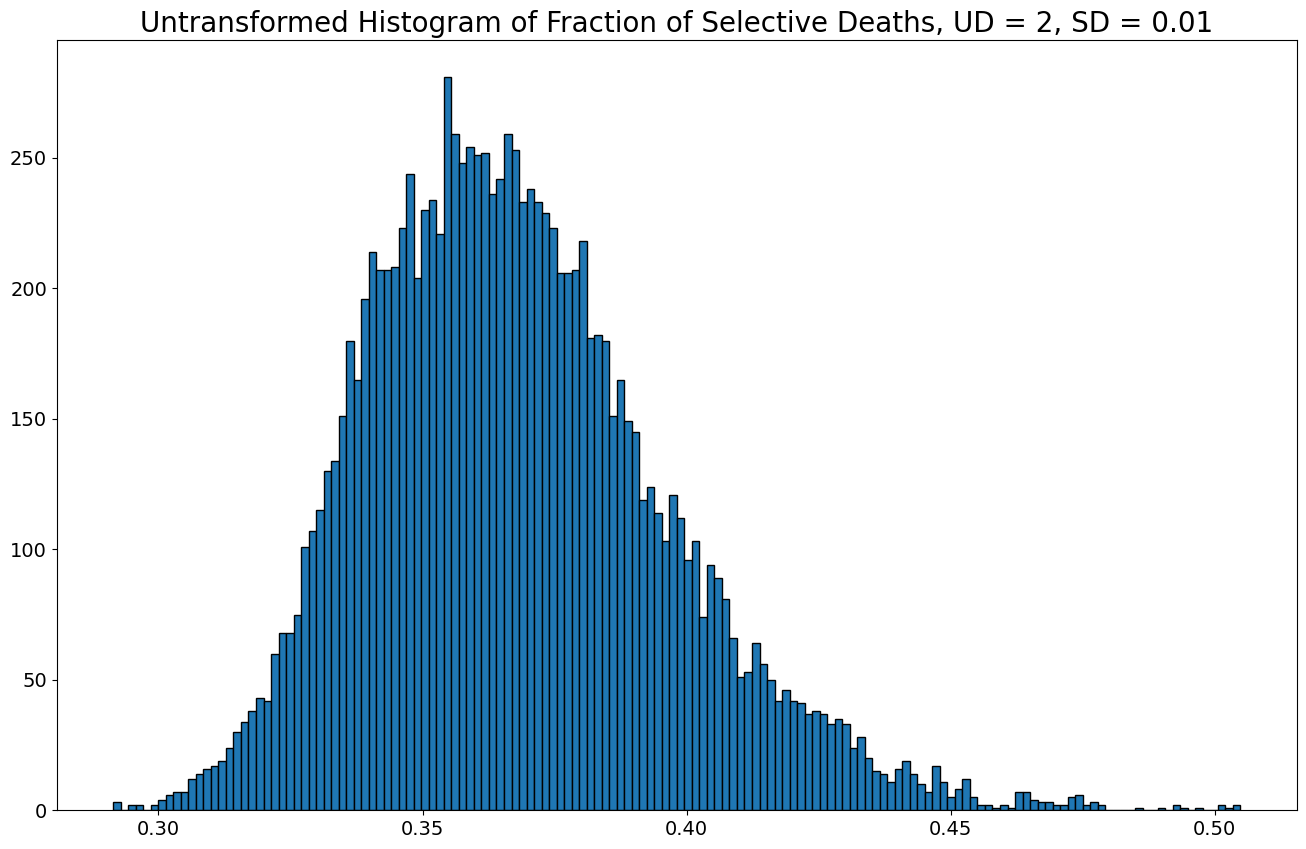

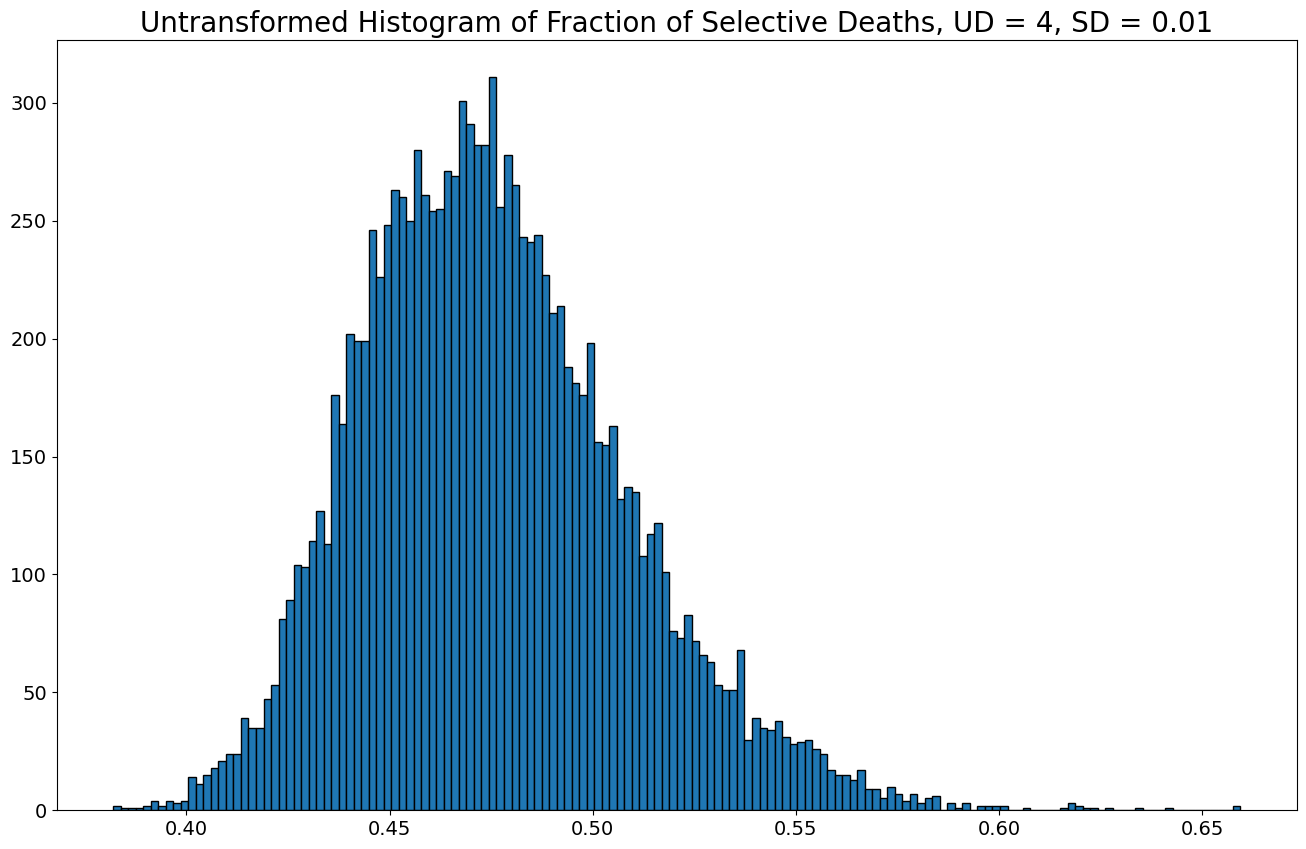

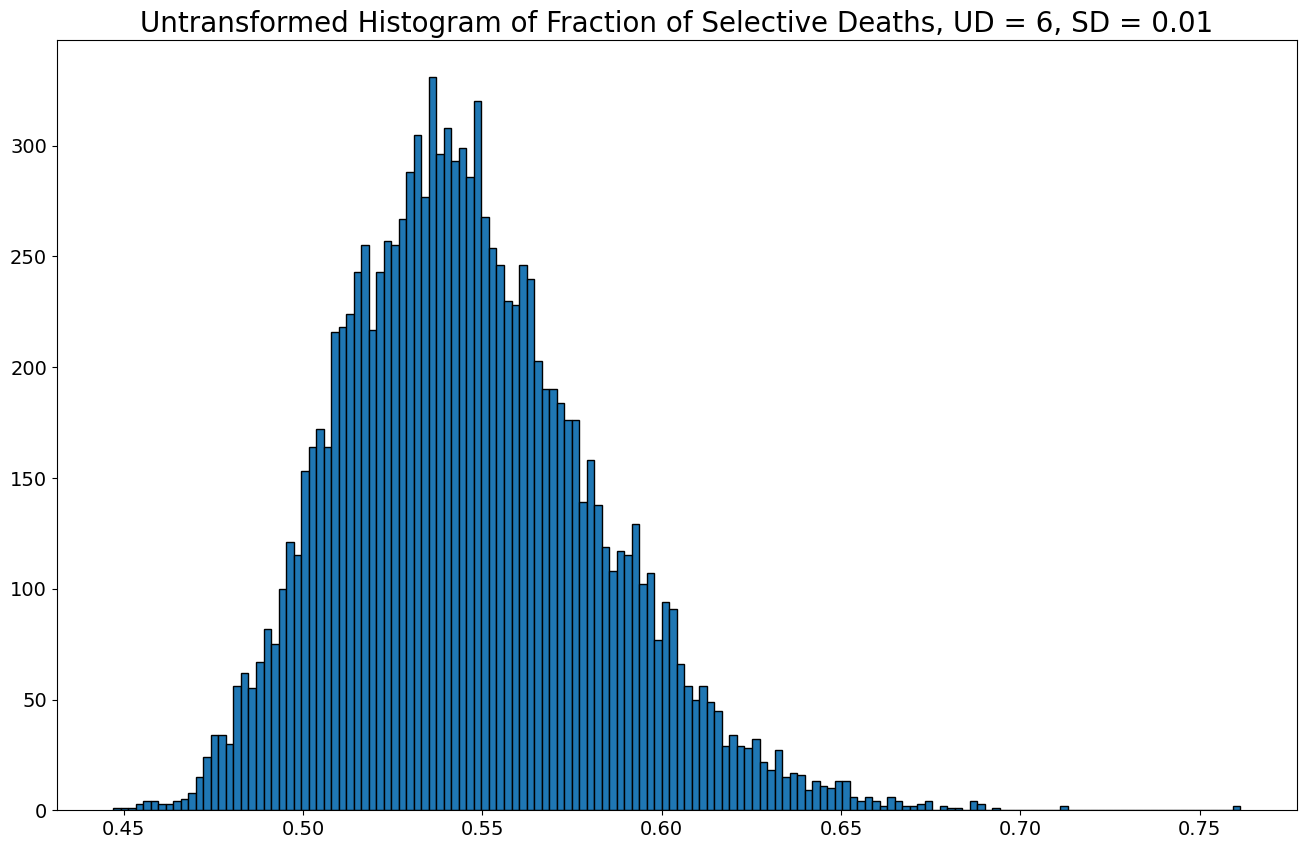

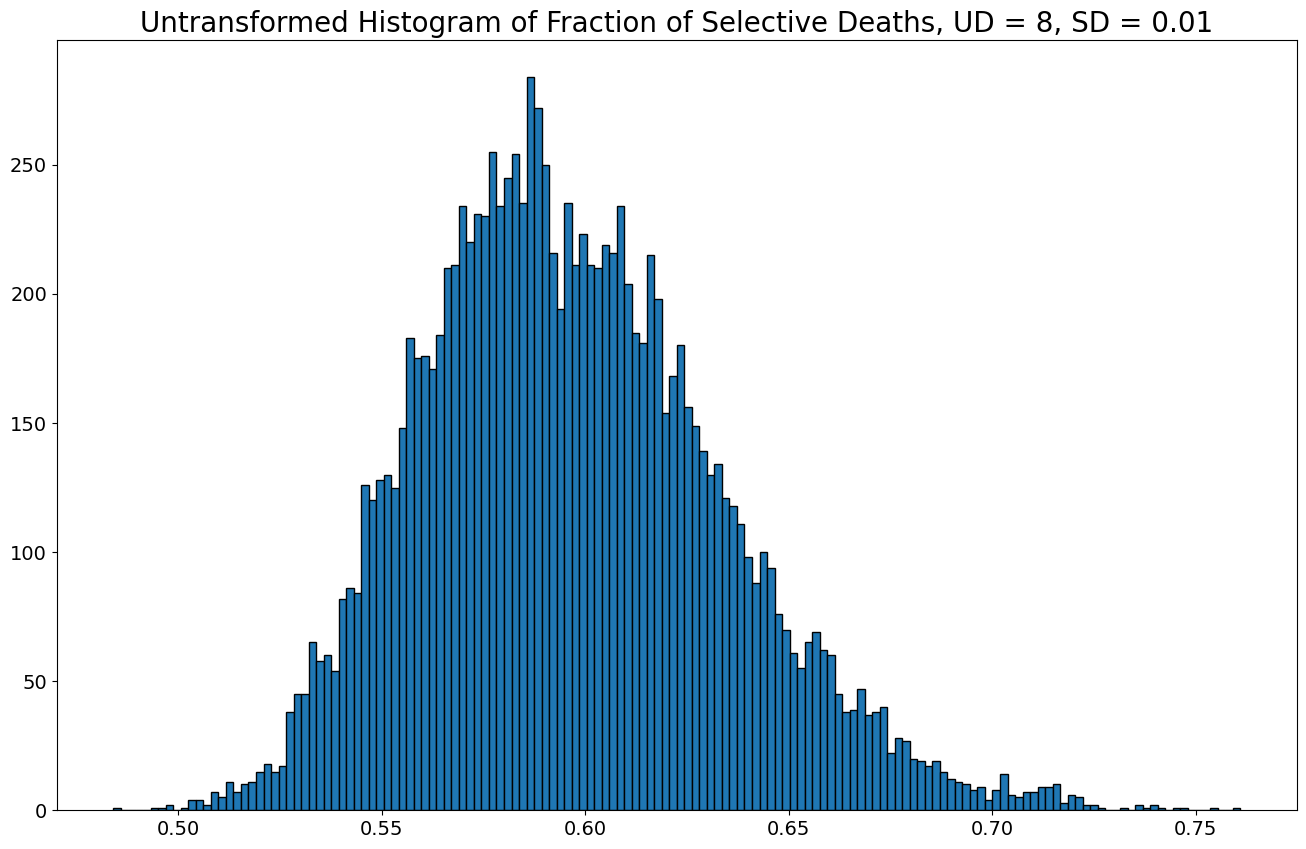

In [ ]:
# S. Death Histograms: Burn-in, Untransformed

bin_count = 150 

for (sd, (ud, data)) in sliced_data: 
    plt.figure(figsize=(16, 10))
    plt.title("Untransformed Histogram of Fraction of Selective Deaths, UD = " + str(ud) + ", SD = " +(sd[3:]))
    plt.hist(data, bin_count, edgecolor = "black")

    #plt.savefig(output_path + str(sd) + "_untransformed_ud-" + str(ud) + "_histogram_bins-" + str(bin_count) + ".png", dpi=300, bbox_inches='tight')


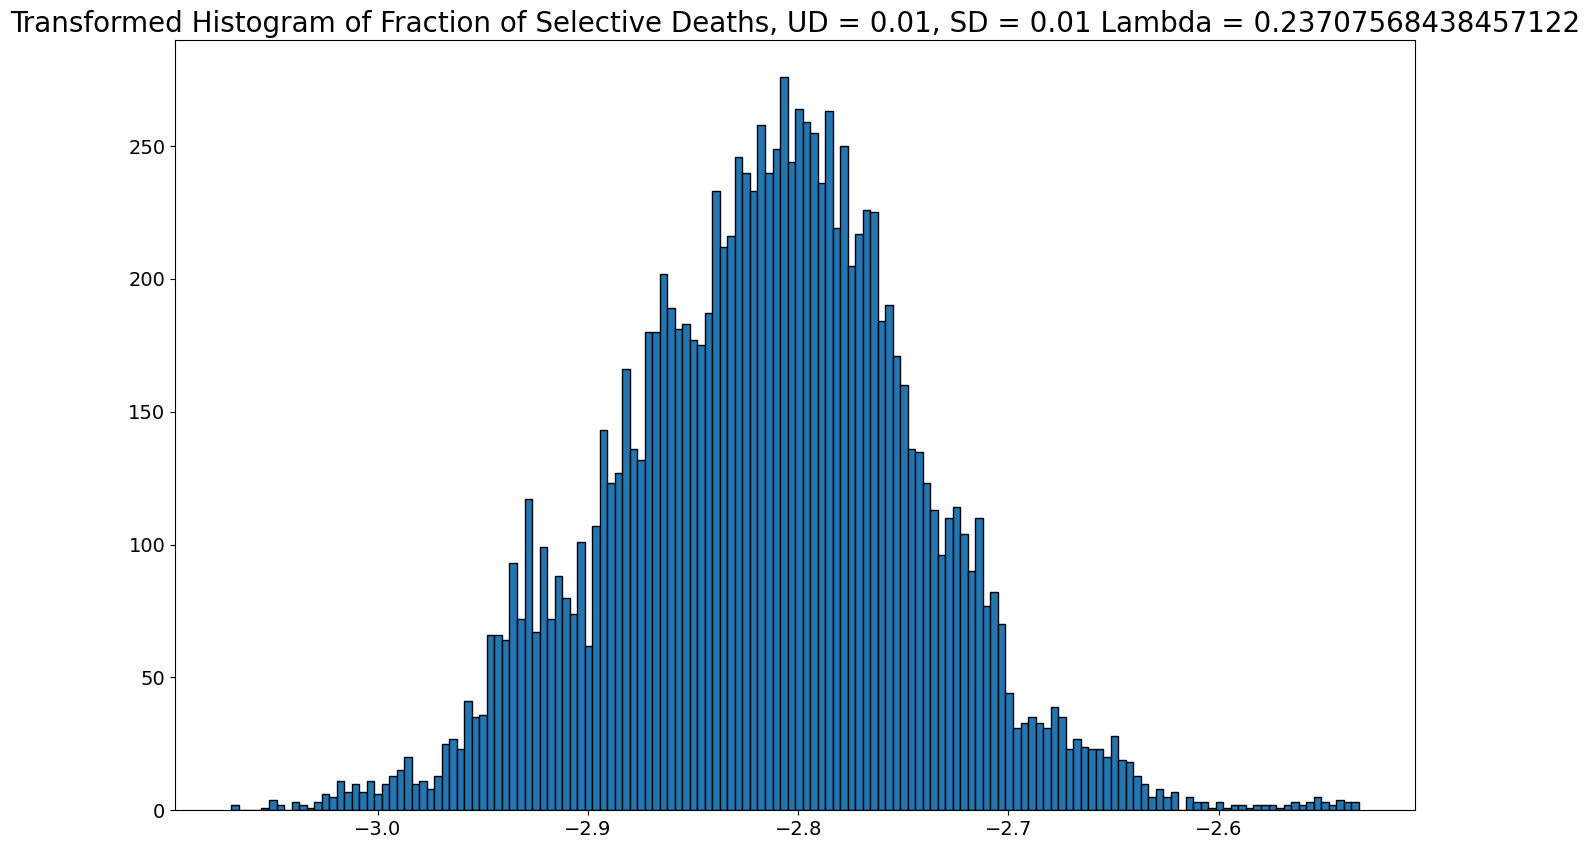

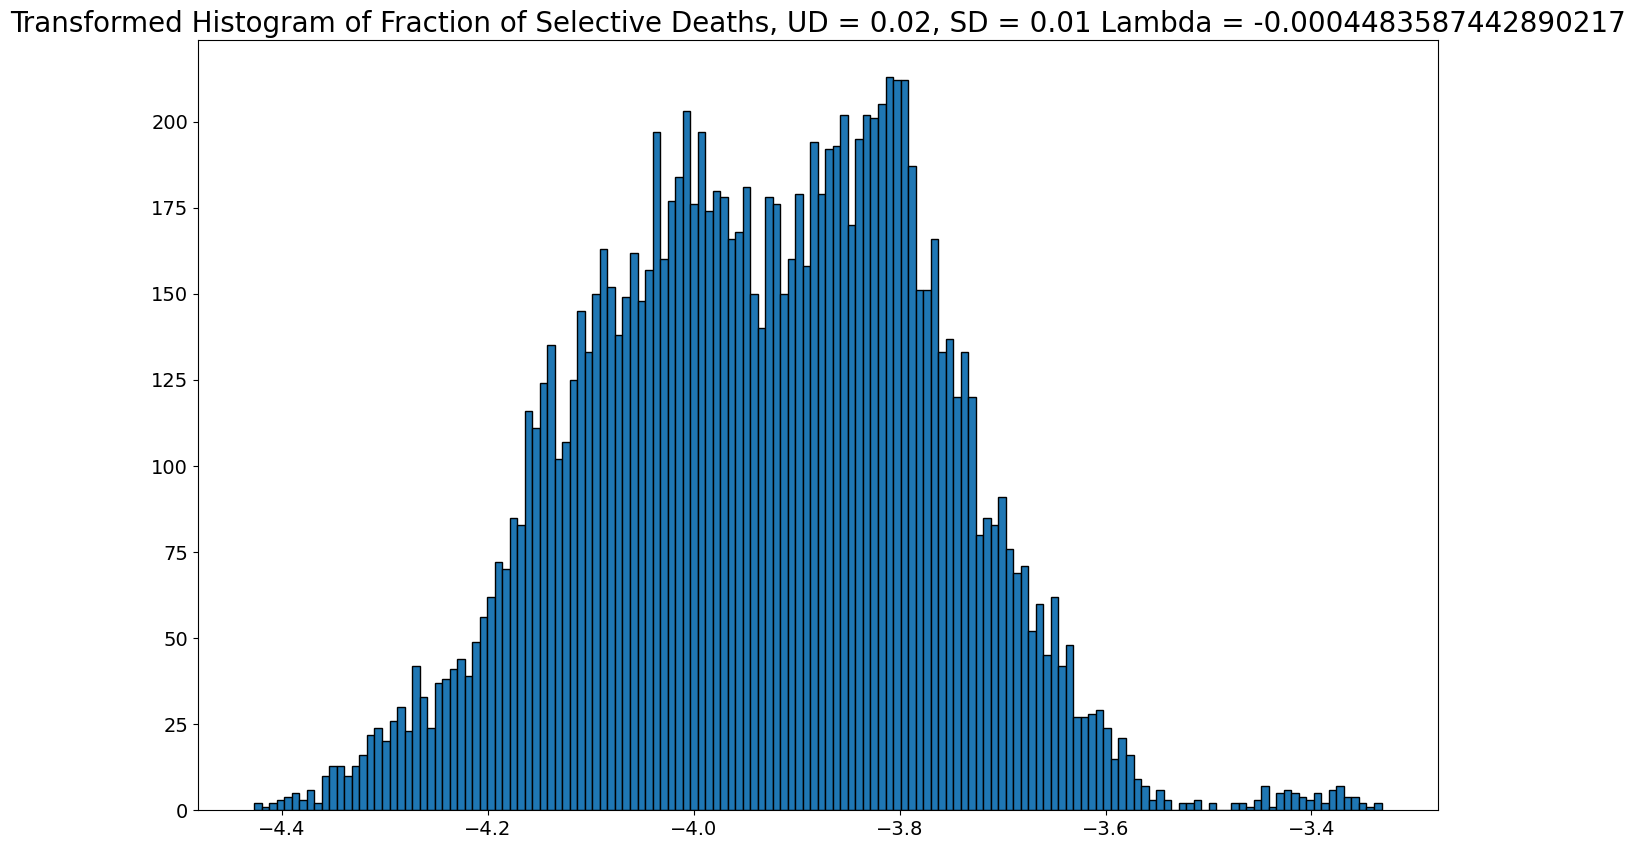

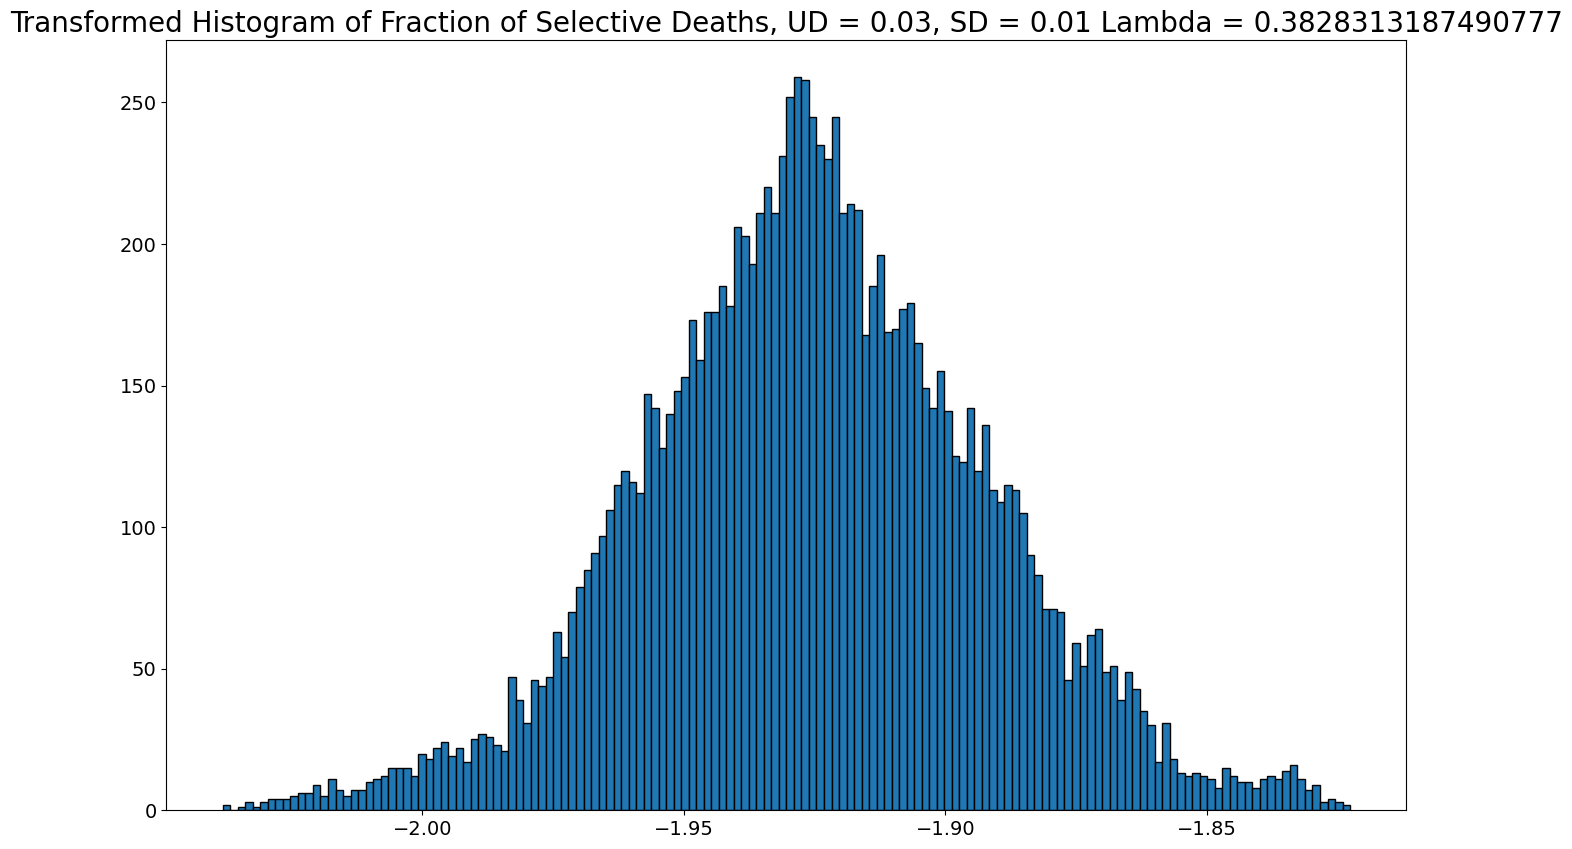

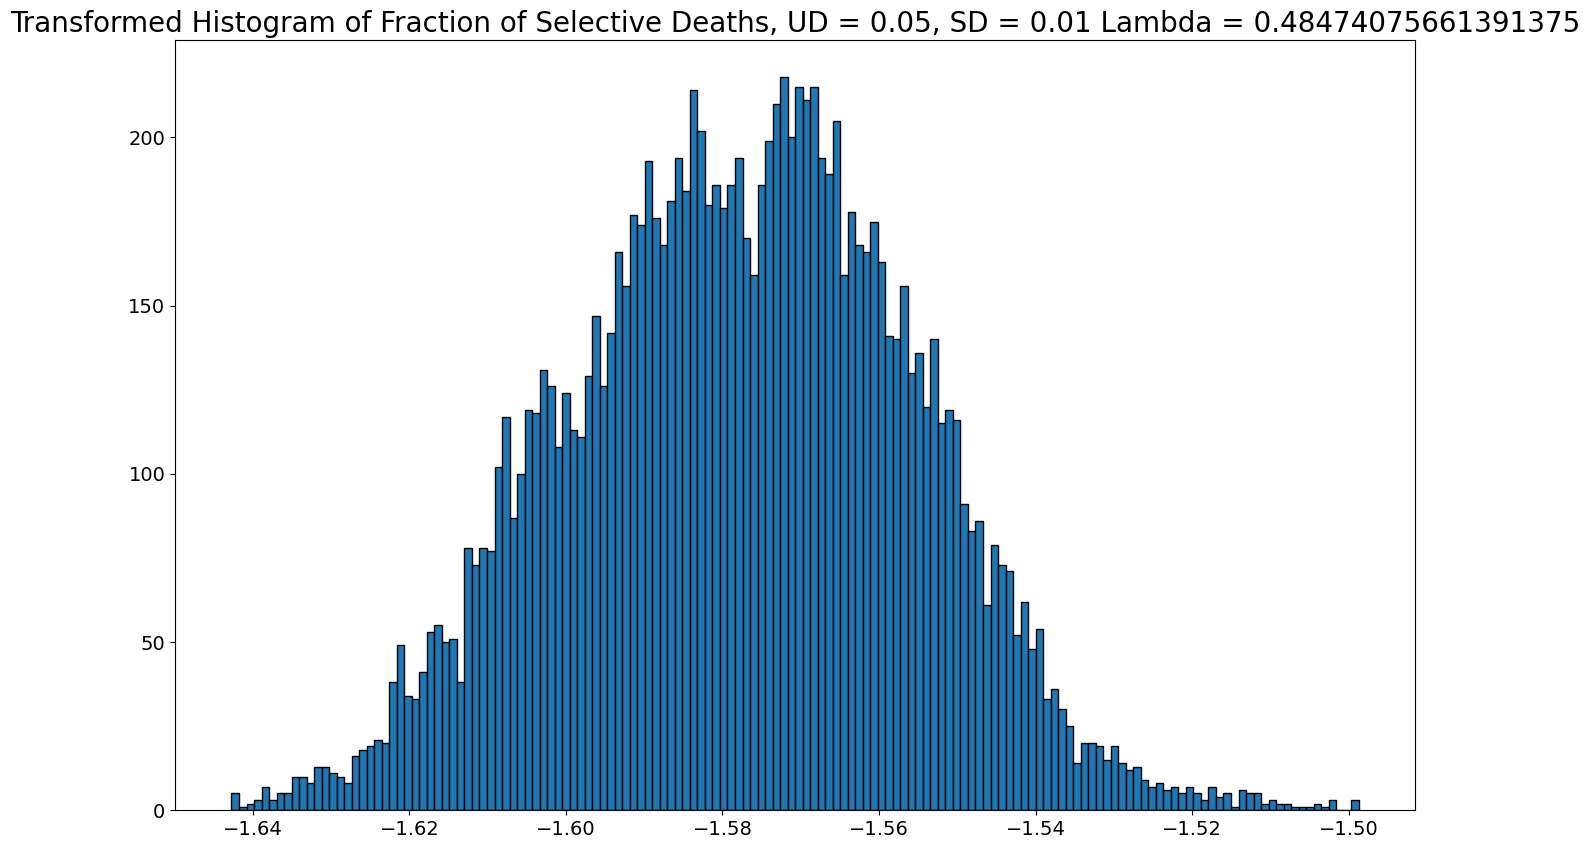

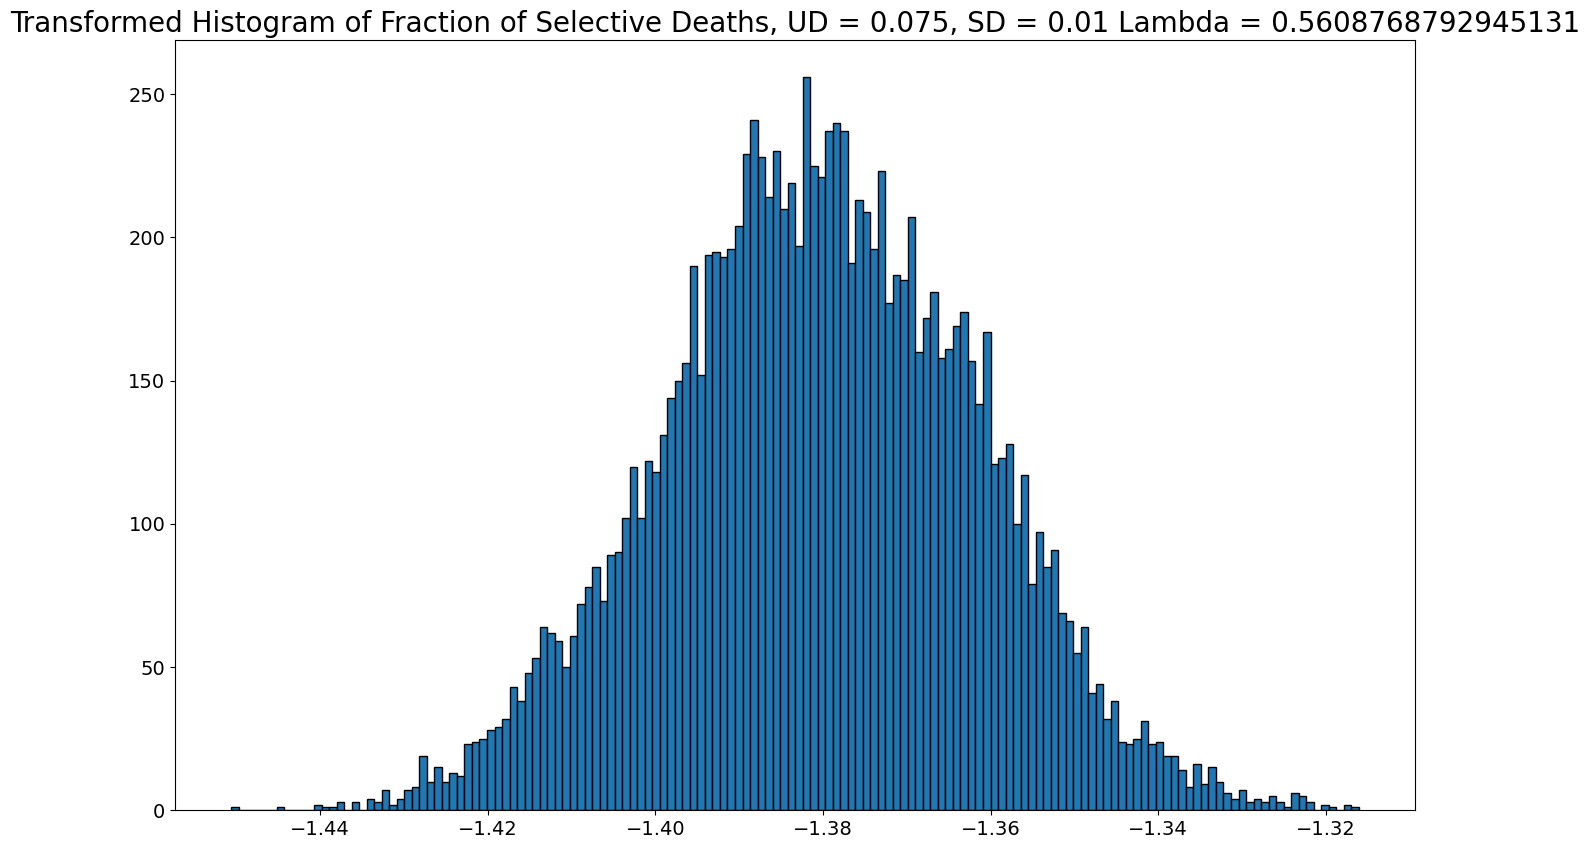

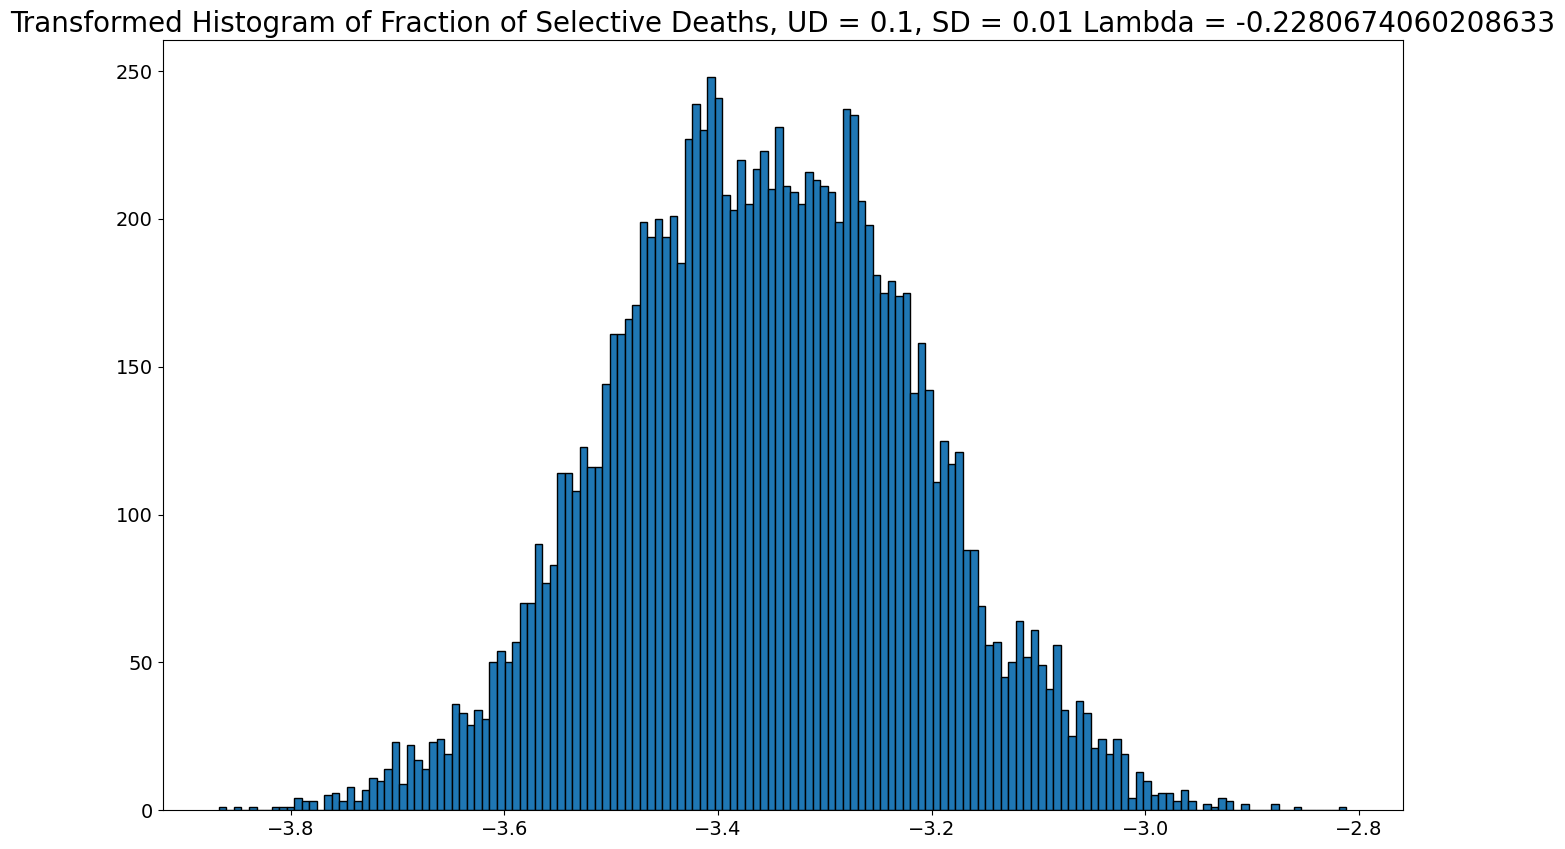

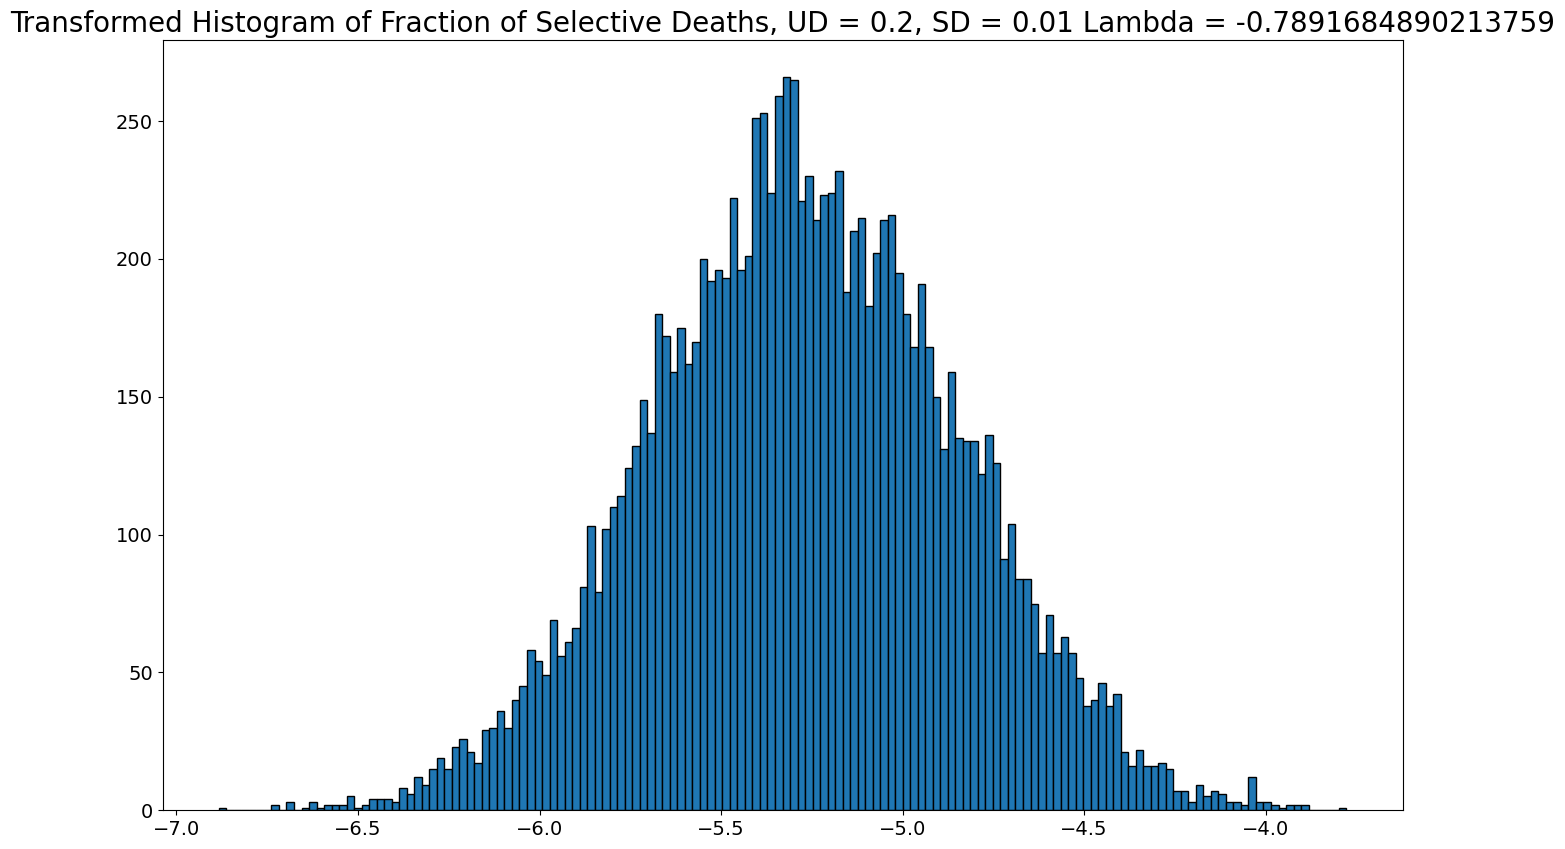

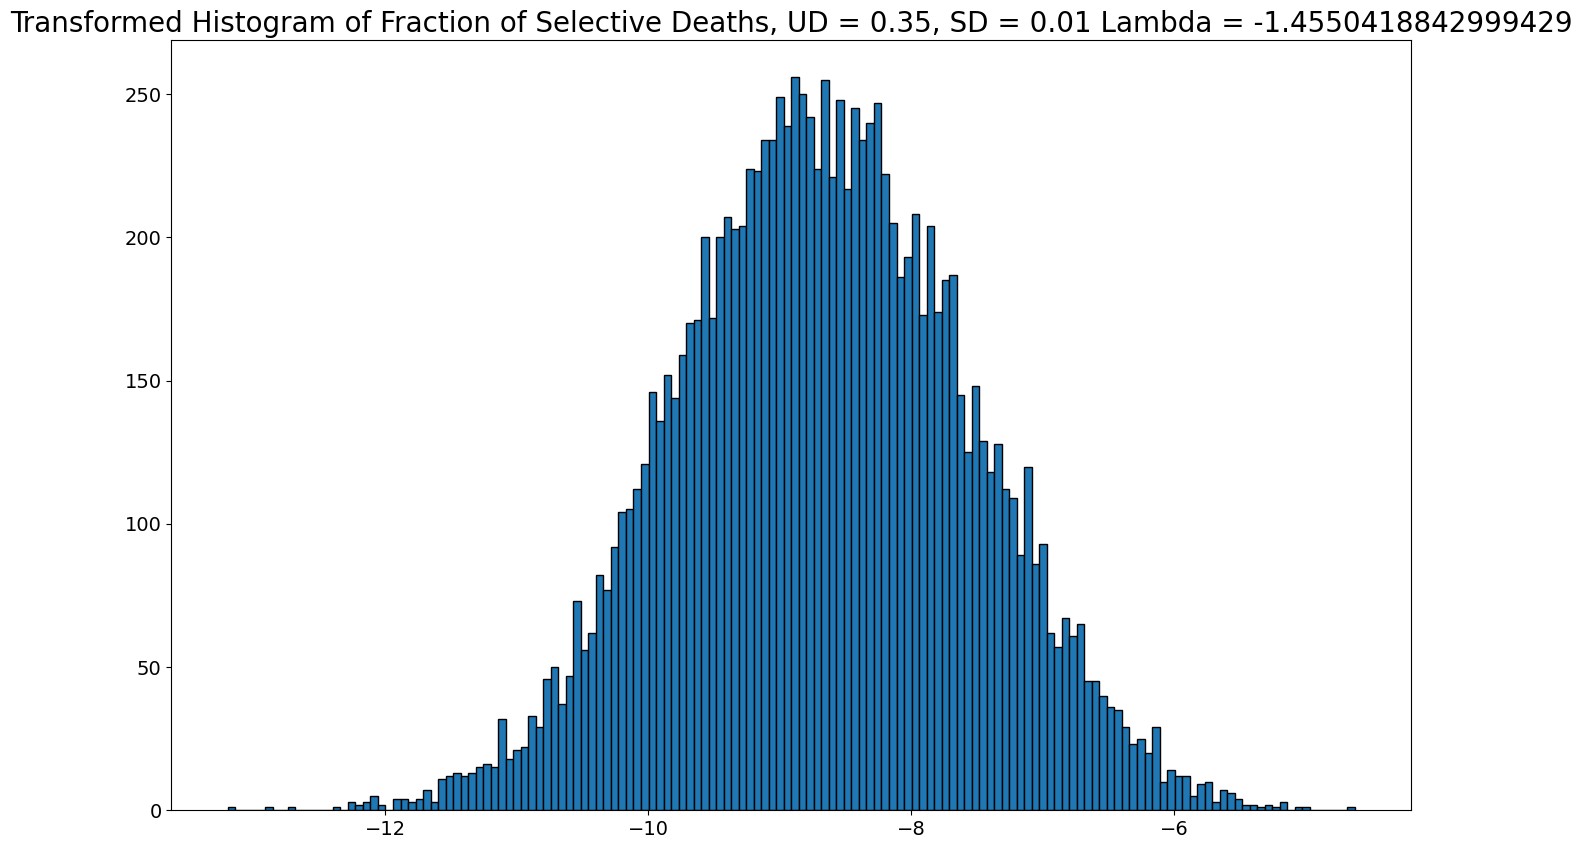

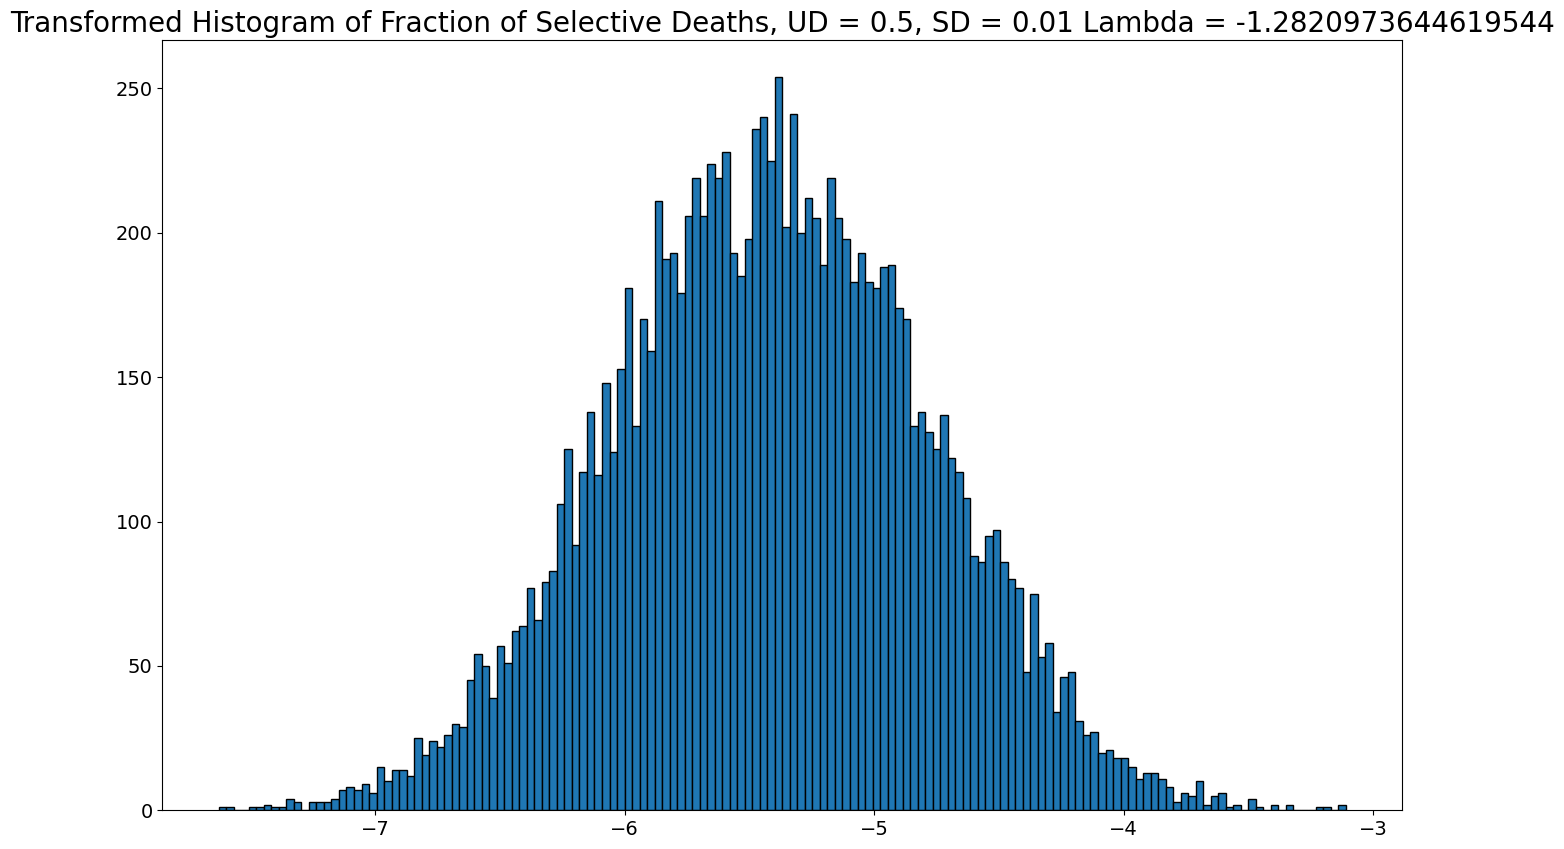

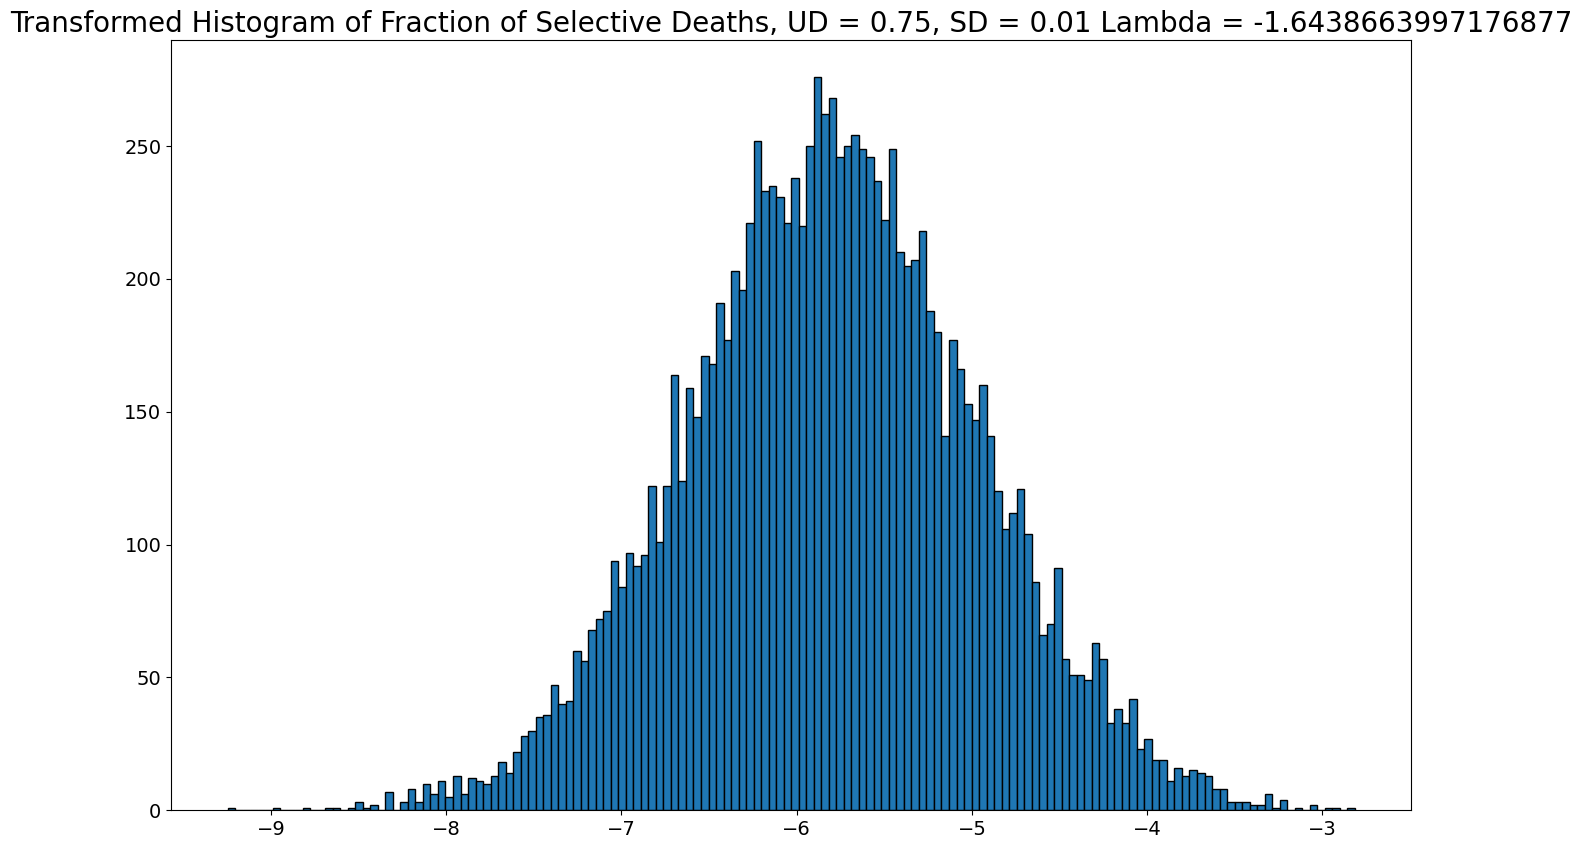

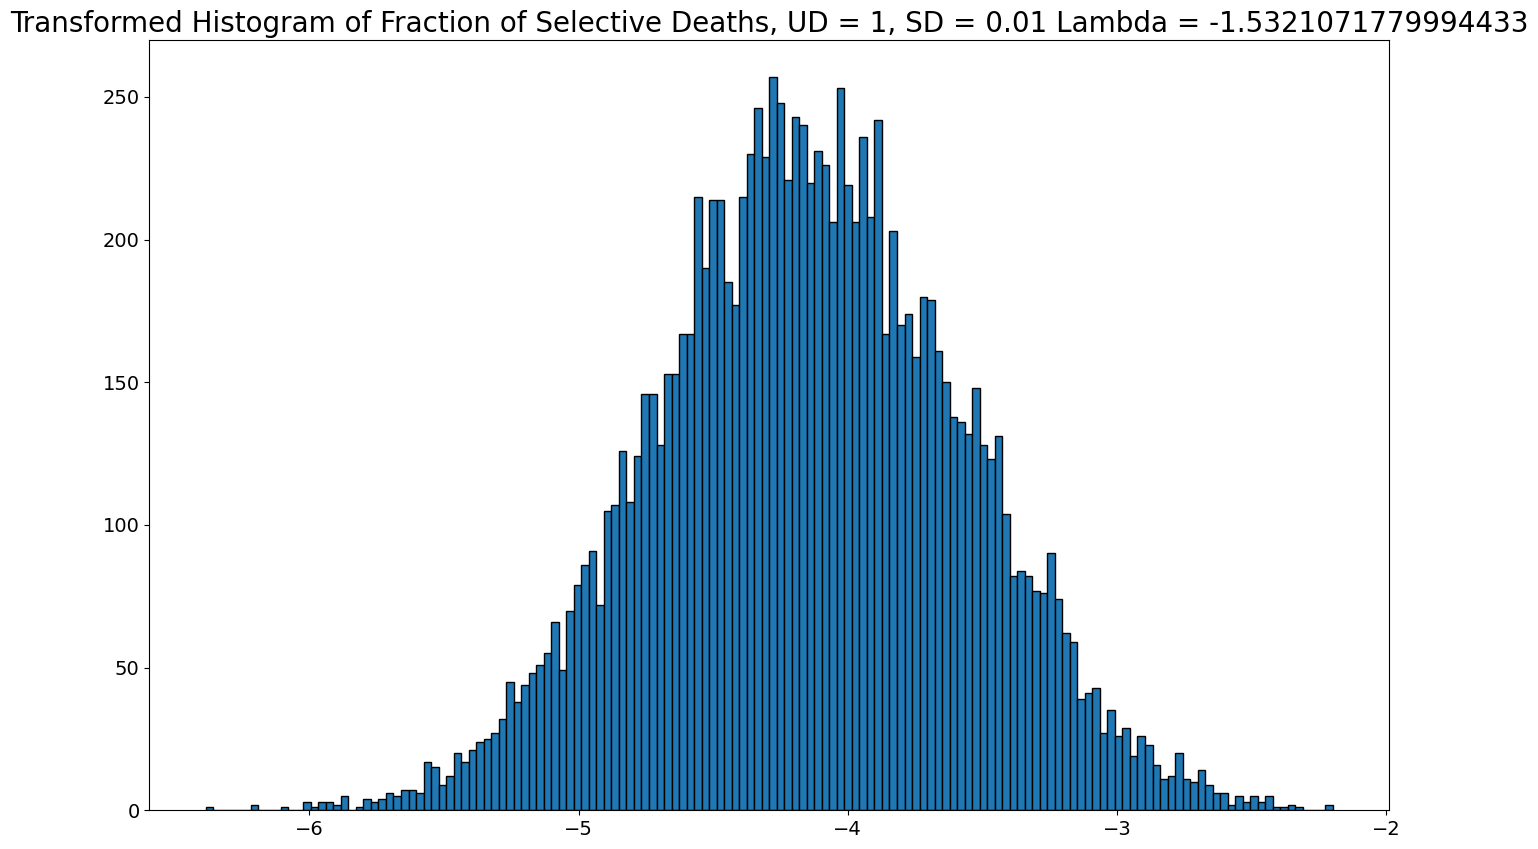

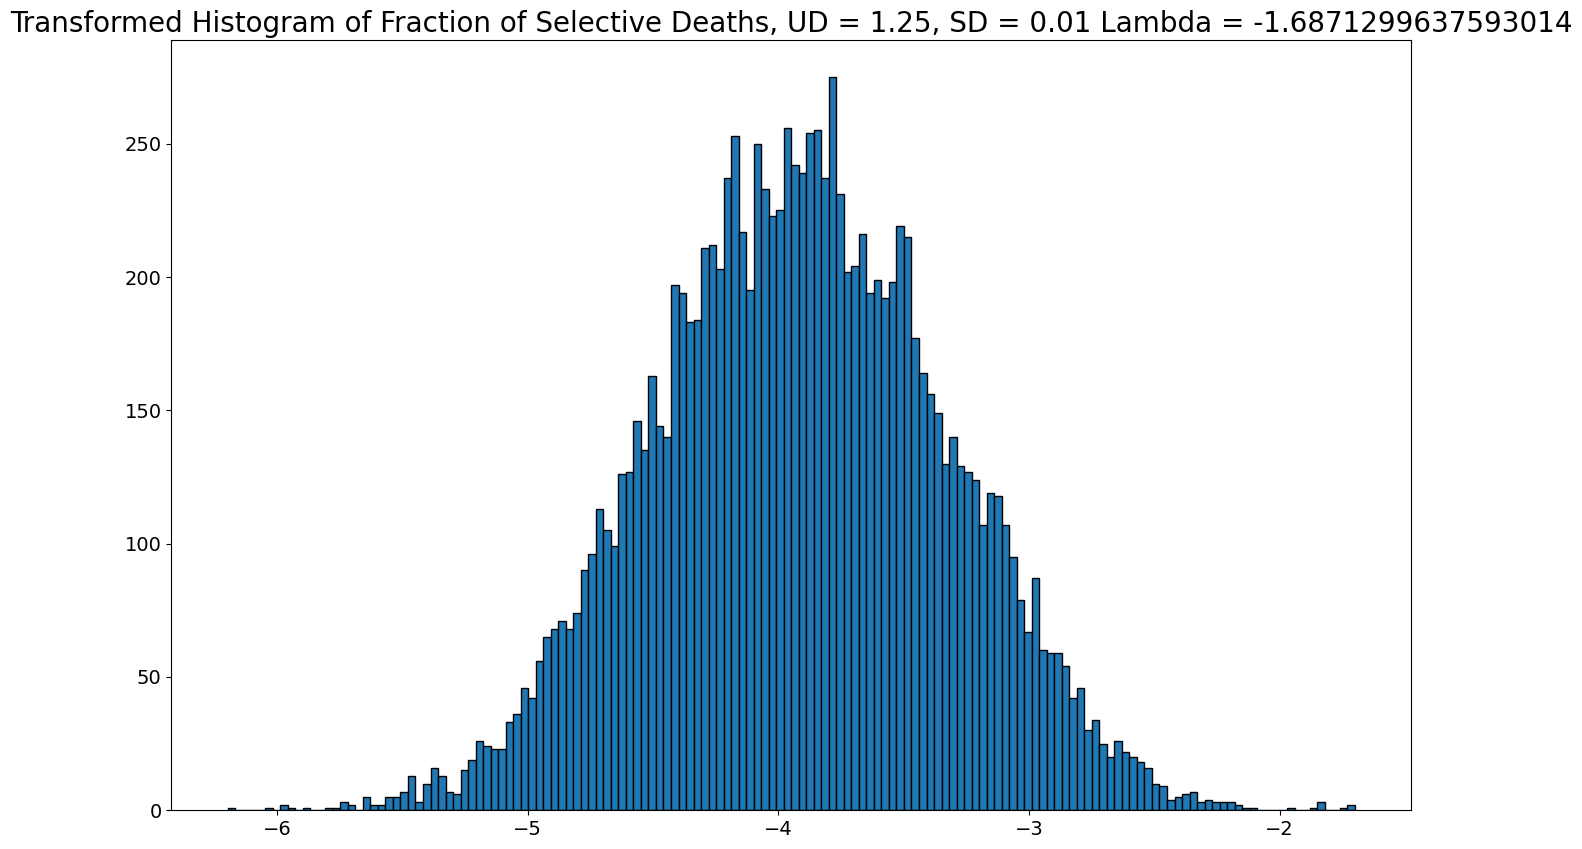

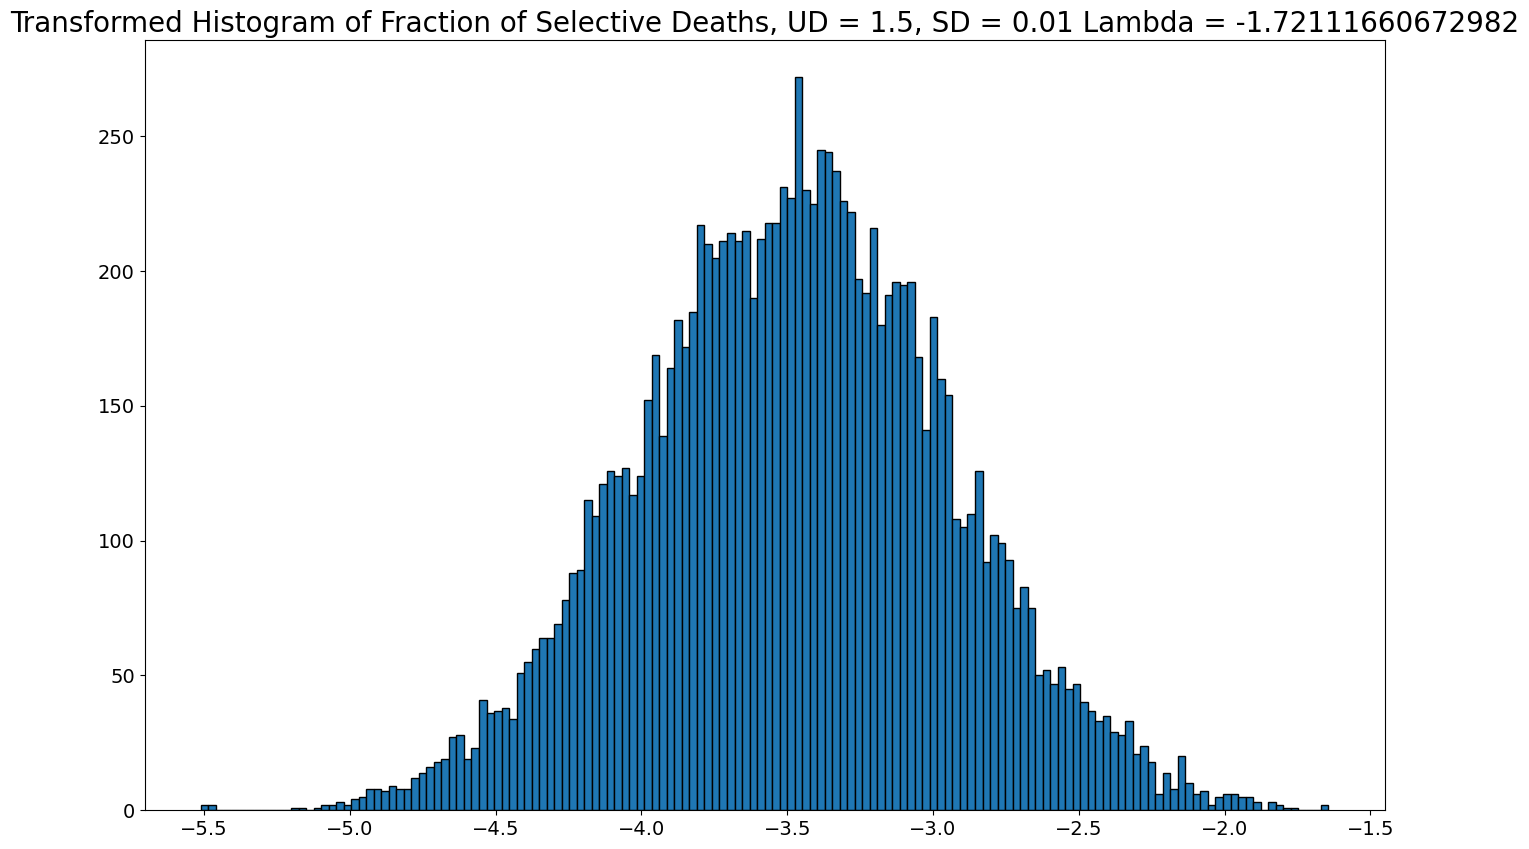

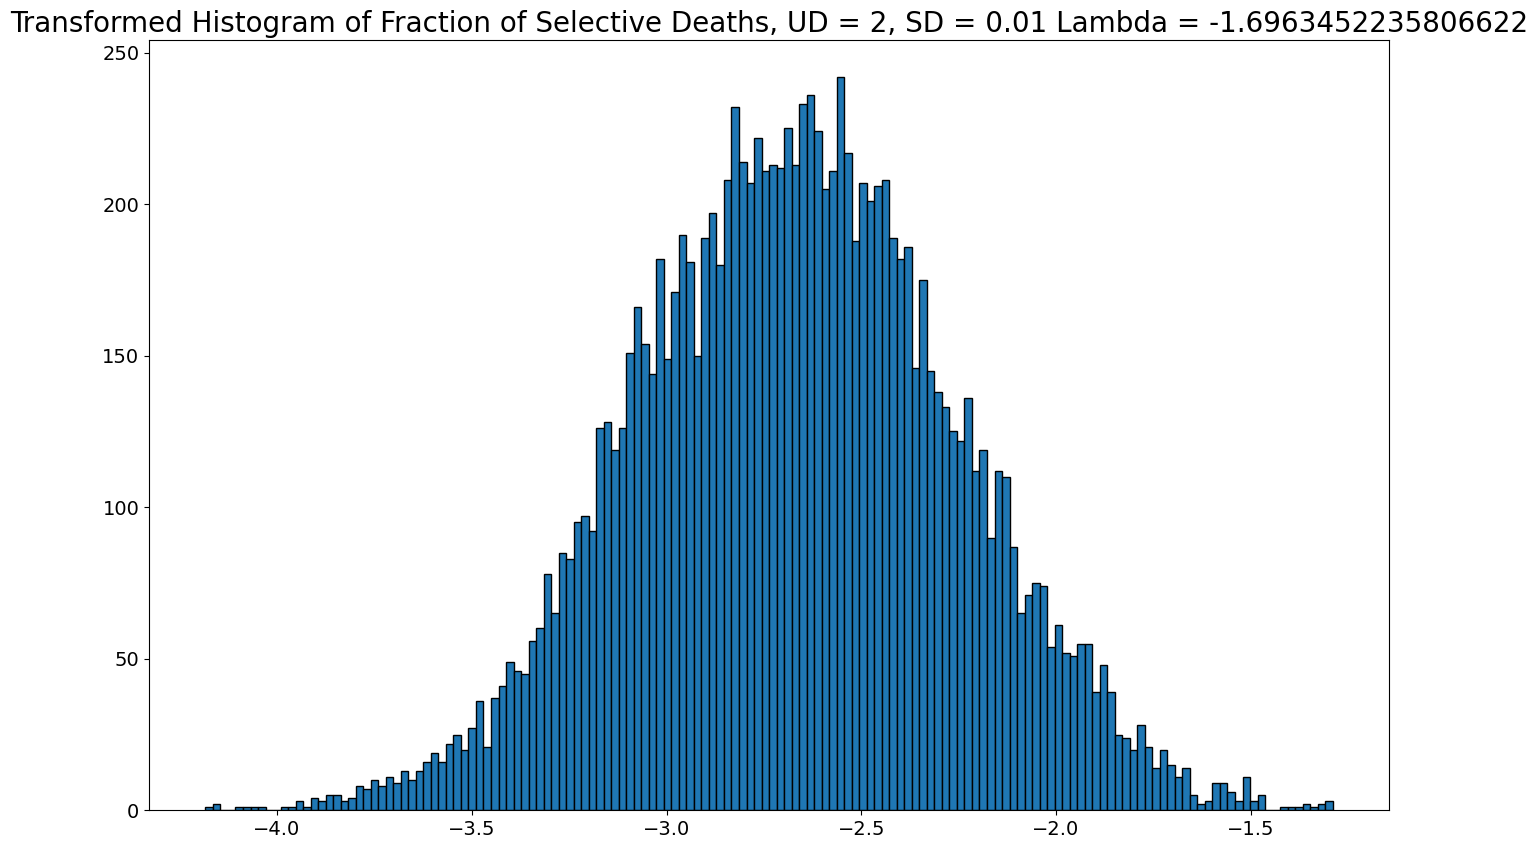

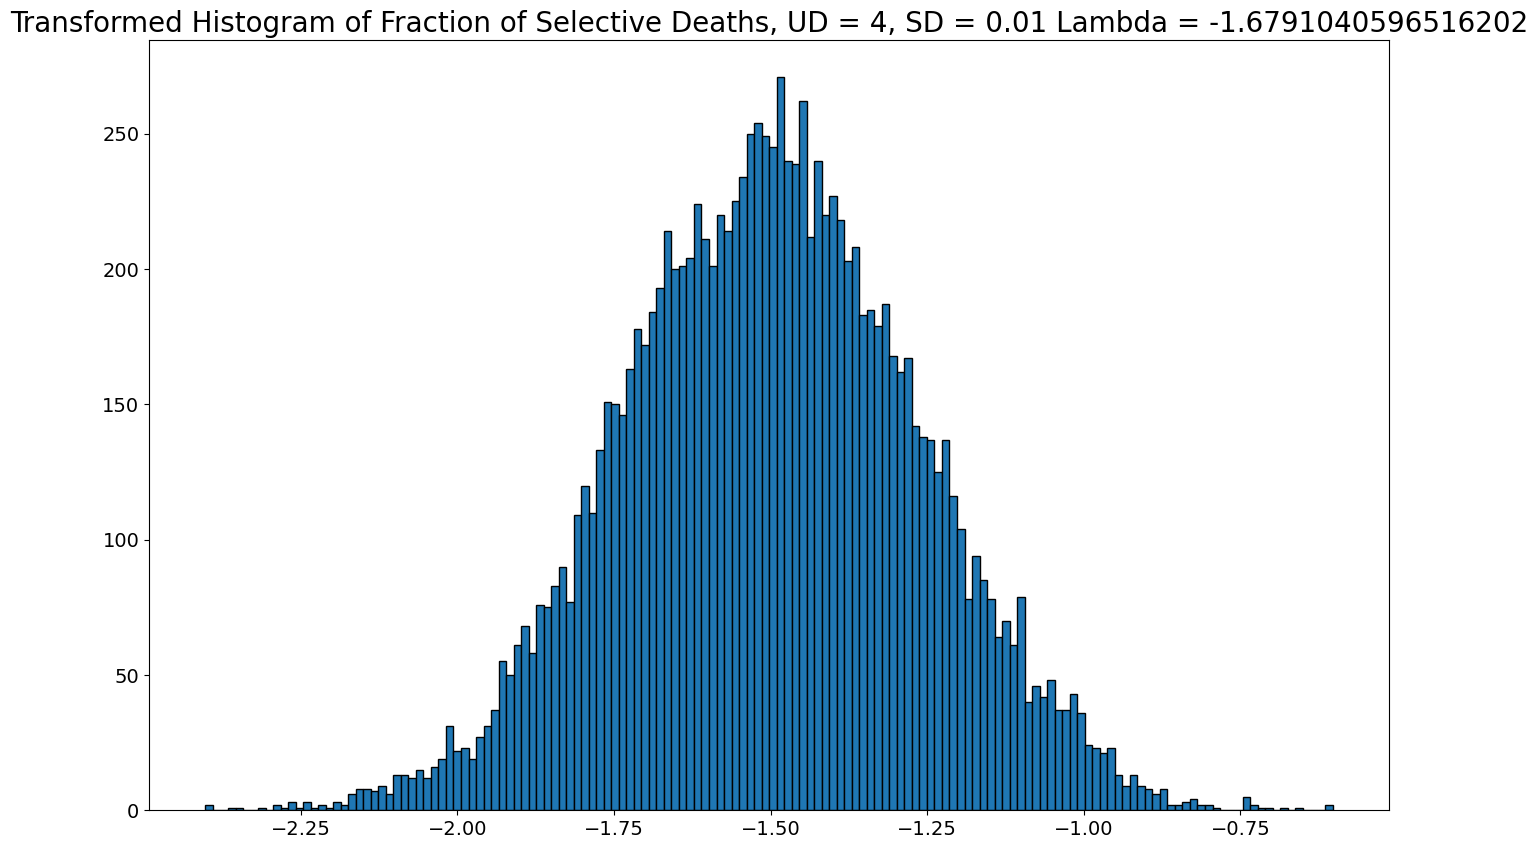

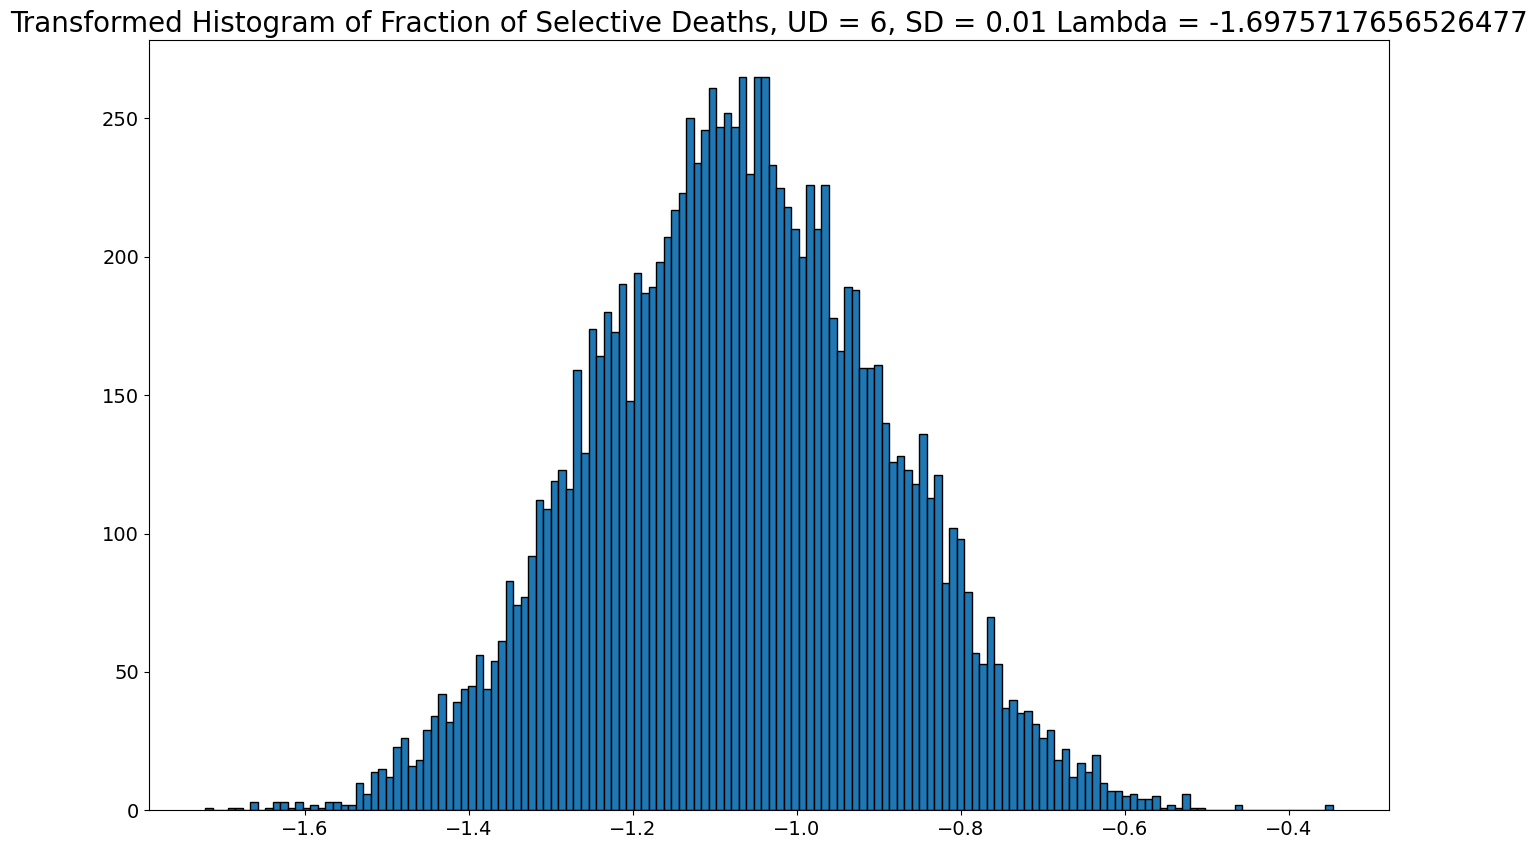

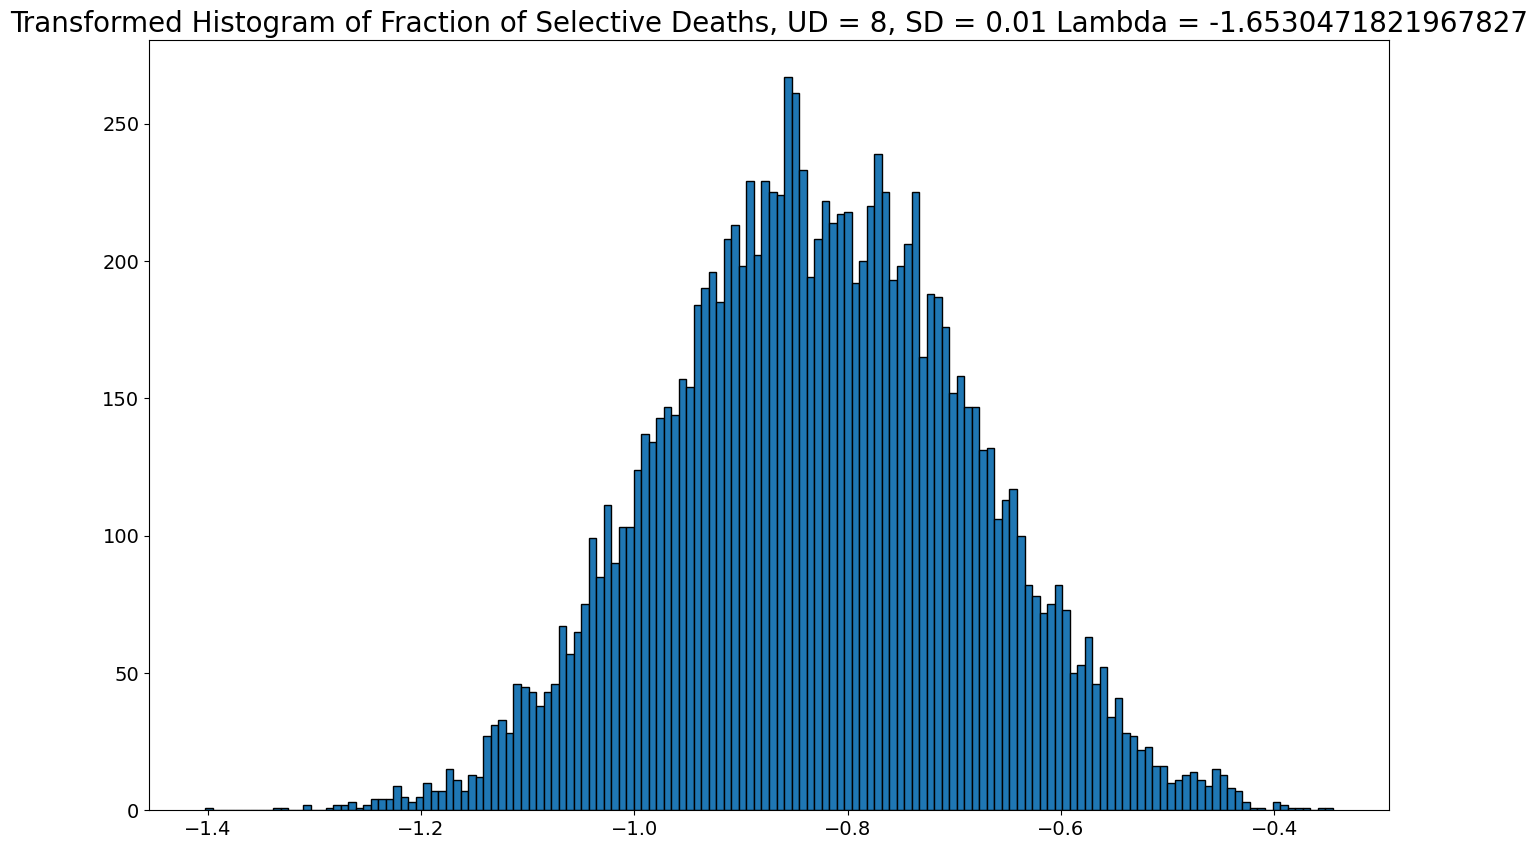

In [ ]:
# S. Death Histograms: Burn-in, Transformed

import cmath
plot = True

bin_count = 150 

transformed_datasets = parse_data.transform_data(sliced_data)

# if plot:
#     for ((sd, (ud, (transformed_data, transformed_lambda)))) in transformed_datasets: 
#         plt.figure(figsize=(16, 10))
#         plt.title("Transformed Histogram of Fraction of Selective Deaths, UD = " + str(ud) + ", SD = " + str(sd[3:]) + " Lambda = " + str(transformed_lambda))
#         plt.hist(transformed_data, bin_count, edgecolor = "black")

for (sd, (ud, (transformed_data, transformed_lambda, transformed_mean))) in transformed_datasets: 
    # Back-transforming data

    plt.figure(figsize=(16, 10))
    plt.title("Transformed Histogram of Fraction of Selective Deaths, UD = " + str(ud) + ", SD = " + str(sd[3:]) + " Lambda = " + str(transformed_lambda))
    plt.hist(transformed_data, bin_count, edgecolor = "black")

    #plt.savefig(output_path + "exp" + str(sd) + "_transformed_ud-" + str(ud) + "_histogram_bins-" + str(bin_count) + ".png", dpi=300, bbox_inches='tight')